In [ ]:
  from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# %% --- Cell 1: Setup & Mount Drive ---
!pip install -q torch torchvision scikit-learn matplotlib seaborn opencv-python-headless tqdm grad-cam

import os, random, shutil, numpy as np, cv2, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import Counter
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# XAI imports
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")
from sklearn.manifold import TSNE


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 22.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch: 2.10.0+cpu | CUDA: False


In [ ]:
# %% --- Cell 2: Config ---
class CONFIG:
    # ===== ĐƯỜNG DẪN — SỬA LẠI THEO DRIVE CỦA BẠN =====
    DRIVE_ROOT    = "/content/drive/MyDrive/SMIDS_EfficientNet+CBAM/DATA"
    RAW_DATA_DIR  = os.path.join(DRIVE_ROOT, "/content/drive/MyDrive/SMIDS_EfficientNet+CBAM/SMIDS")       # Chứa 3 thư mục class
    PROCESSED_DIR = os.path.join(DRIVE_ROOT, "data/processed")
    CHECKPOINT_DIR= os.path.join(DRIVE_ROOT, "outputs/checkpoints")
    FIGURES_DIR   = os.path.join(DRIVE_ROOT, "outputs/figures")

    NUM_CLASSES  = 3
    CLASS_NAMES  = ["Normal_Sperm", "Abnormal_Sperm", "Non_Sperm"]
    IMAGE_SIZE   = 224           # ← Khôi phục 224 (ban đầu)
    BATCH_SIZE   = 16
    NUM_WORKERS  = 2
    SEED         = 42

    # Fine-tuning 3 stages (tăng epochs)
    EPOCHS  = [10, 15, 12]      # stage1, stage2, stage3
    LRS     = [1e-3, 1e-4, 1e-5]
    WEIGHT_DECAY = 1e-4
    PATIENCE     = 7             # Tăng patience
    LABEL_SMOOTHING = 0.1        # Giúp generalization

    USE_AMP          = True
    GRAD_ACCUM_STEPS = 2   # effective batch = 32

    # Preprocessing — khôi phục bộ lọc ban đầu
    FILTER_TYPE  = "bilateral"   # "bilateral" (ban đầu) hoặc "gaussian"
    CLAHE_CLIP   = 2.0
    CLAHE_TILE   = (8, 8)        # ← Khôi phục (8,8)

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

for d in [CONFIG.PROCESSED_DIR, CONFIG.CHECKPOINT_DIR, CONFIG.FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# %% --- Cell 3: Seed & EarlyStopping ---
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(CONFIG.SEED)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.early_stop = 0, None, False
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"⛔ Early stopping (patience={self.patience})")
        else:
            self.best_loss = val_loss; self.counter = 0


In [ ]:
# %% --- Cell 4: Preprocessing Pipeline (4 bước) ---
def denoise_bilateral(img):
    """Bước 1: Khử nhiễu Bilateral Filter."""
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

def apply_clahe(img, clip_limit=2.0, tile_size=(8,8)):
    """Bước 2: CLAHE trên kênh L (LAB)."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

def sharpen_unsharp(img, sigma=1.0, amount=0.8):
    """Bước 3: Làm sắc nét Unsharp Masking."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1.0 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def resize_with_padding(img, target_size=224, pad_color=0):
    """Bước 4: Resize giữ tỷ lệ + Padding."""
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((target_size, target_size, 3), pad_color, dtype=np.uint8)
    y_off, x_off = (target_size - new_h) // 2, (target_size - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return canvas

def preprocess_image(image_path, target_size=224):
    """Full pipeline: Bilateral → CLAHE → Unsharp Mask → Resize+Pad."""
    img = cv2.imread(str(image_path))
    if img is None: raise ValueError(f"Không đọc được: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = denoise_bilateral(img)
    img = apply_clahe(img, CONFIG.CLAHE_CLIP, CONFIG.CLAHE_TILE)
    img = sharpen_unsharp(img)
    img = resize_with_padding(img, target_size)
    return img

print("✅ Preprocessing pipeline: Bilateral → CLAHE → Unsharp Mask → Resize+Padding")

✅ Preprocessing pipeline: Bilateral → CLAHE → Unsharp Mask → Resize+Padding


/tmp/ipykernel_2103/684454879.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2103/684454879.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_01_denoise.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


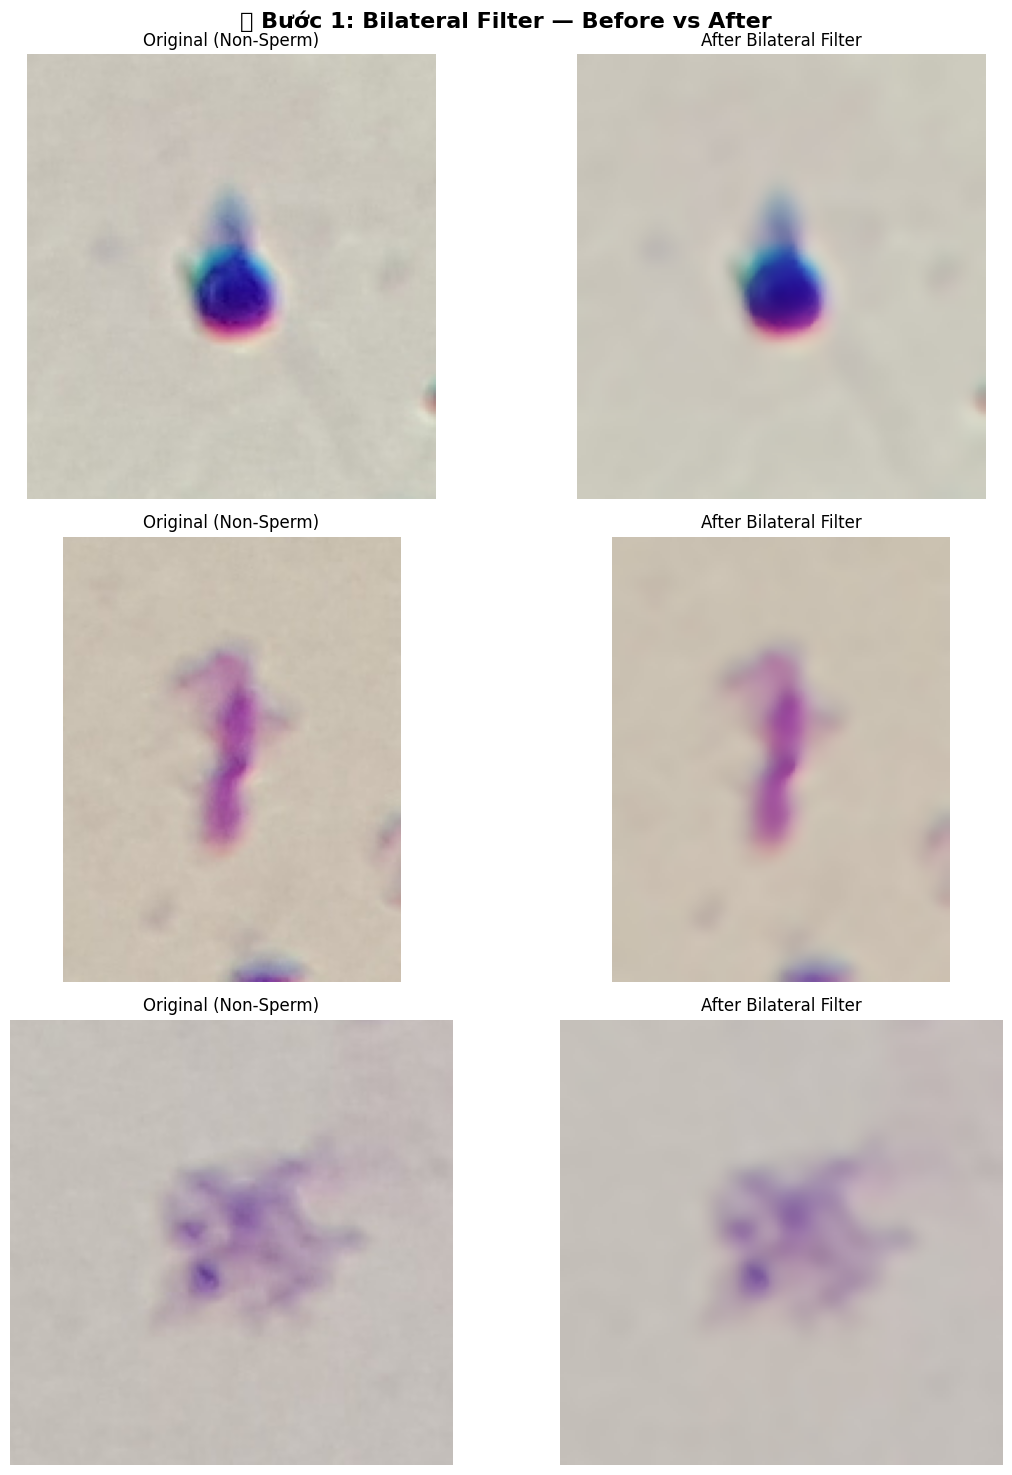

In [ ]:
# %% --- Viz: Bước 1 - Bilateral Filter Before/After ---
sample_paths = list(Path(CONFIG.RAW_DATA_DIR).rglob('*'))
sample_paths = [p for p in sample_paths if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif']][:3]

if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(12, 5*len(sample_paths)))
    fig.suptitle('🔍 Bước 1: Bilateral Filter — Before vs After', fontsize=16, fontweight='bold')
    if len(sample_paths) == 1: axes = axes.reshape(1, -1)
    for i, p in enumerate(sample_paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        denoised = denoise_bilateral(img)
        axes[i,0].imshow(img); axes[i,0].set_title(f'Original ({p.parent.name})')
        axes[i,1].imshow(denoised); axes[i,1].set_title('After Bilateral Filter')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_01_denoise.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không tìm thấy ảnh mẫu để hiển thị")

/tmp/ipykernel_2103/389086463.py:13: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2103/389086463.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_02_clahe.png", dpi=150, bbox_inches='tight')


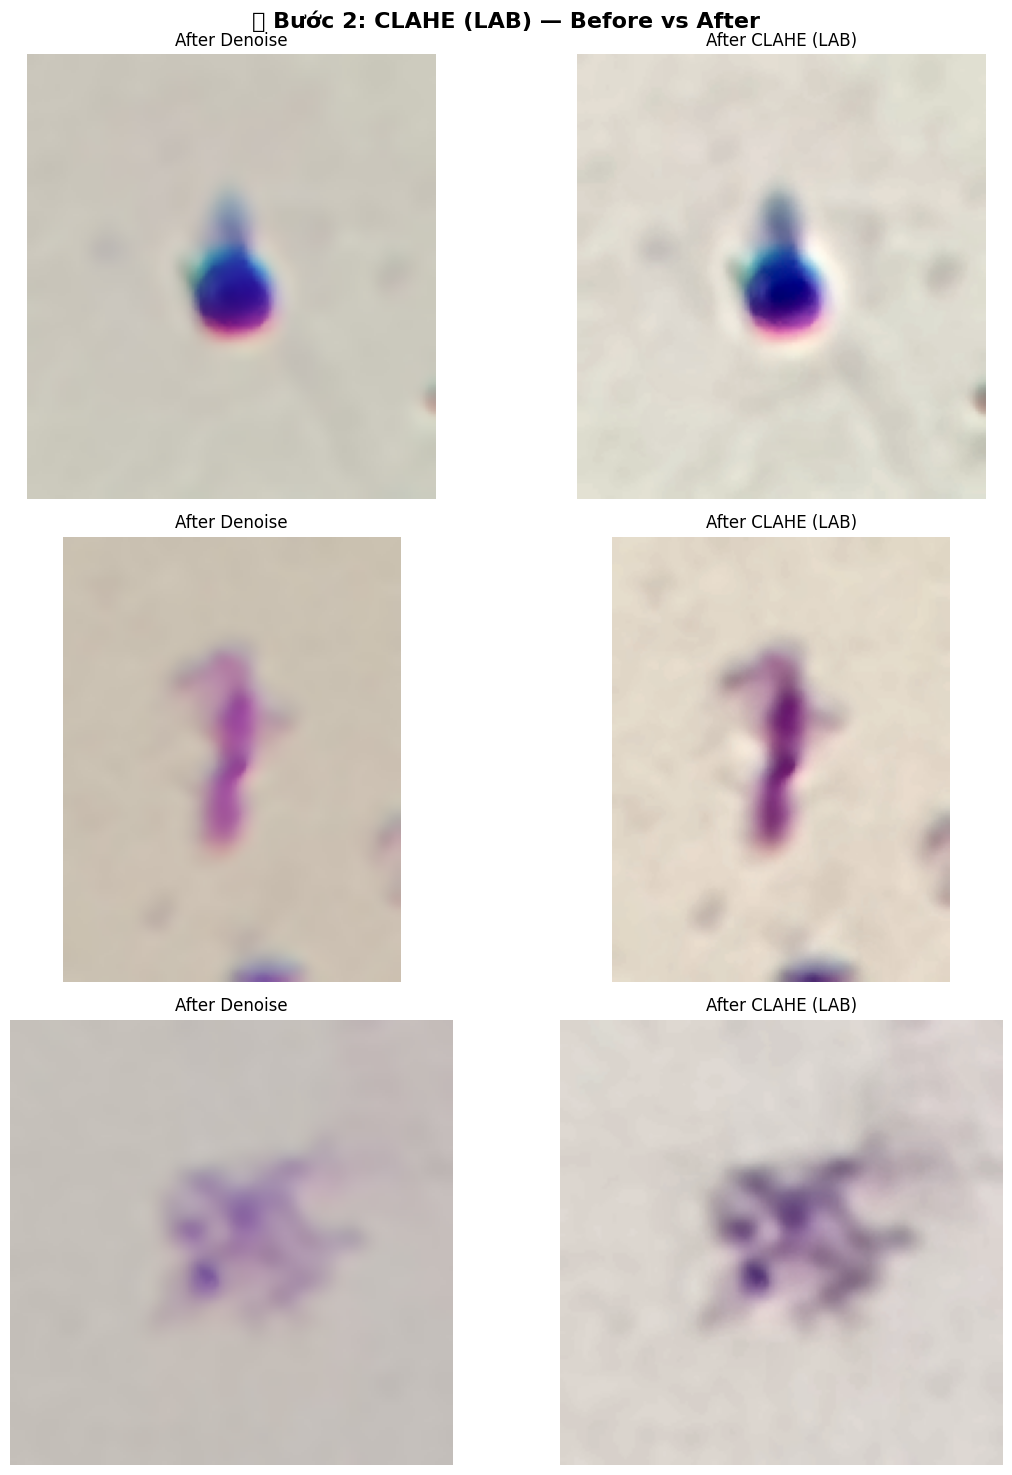

In [ ]:
# %% --- Viz: Bước 2 - CLAHE (LAB) Before/After ---
if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(12, 5*len(sample_paths)))
    fig.suptitle('🔍 Bước 2: CLAHE (LAB) — Before vs After', fontsize=16, fontweight='bold')
    if len(sample_paths) == 1: axes = axes.reshape(1, -1)
    for i, p in enumerate(sample_paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        denoised = denoise_bilateral(img)
        clahe_img = apply_clahe(denoised)
        axes[i,0].imshow(denoised); axes[i,0].set_title('After Denoise')
        axes[i,1].imshow(clahe_img); axes[i,1].set_title('After CLAHE (LAB)')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_02_clahe.png", dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2103/1390073914.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2103/1390073914.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_03_sharpen.png", dpi=150, bbox_inches='tight')


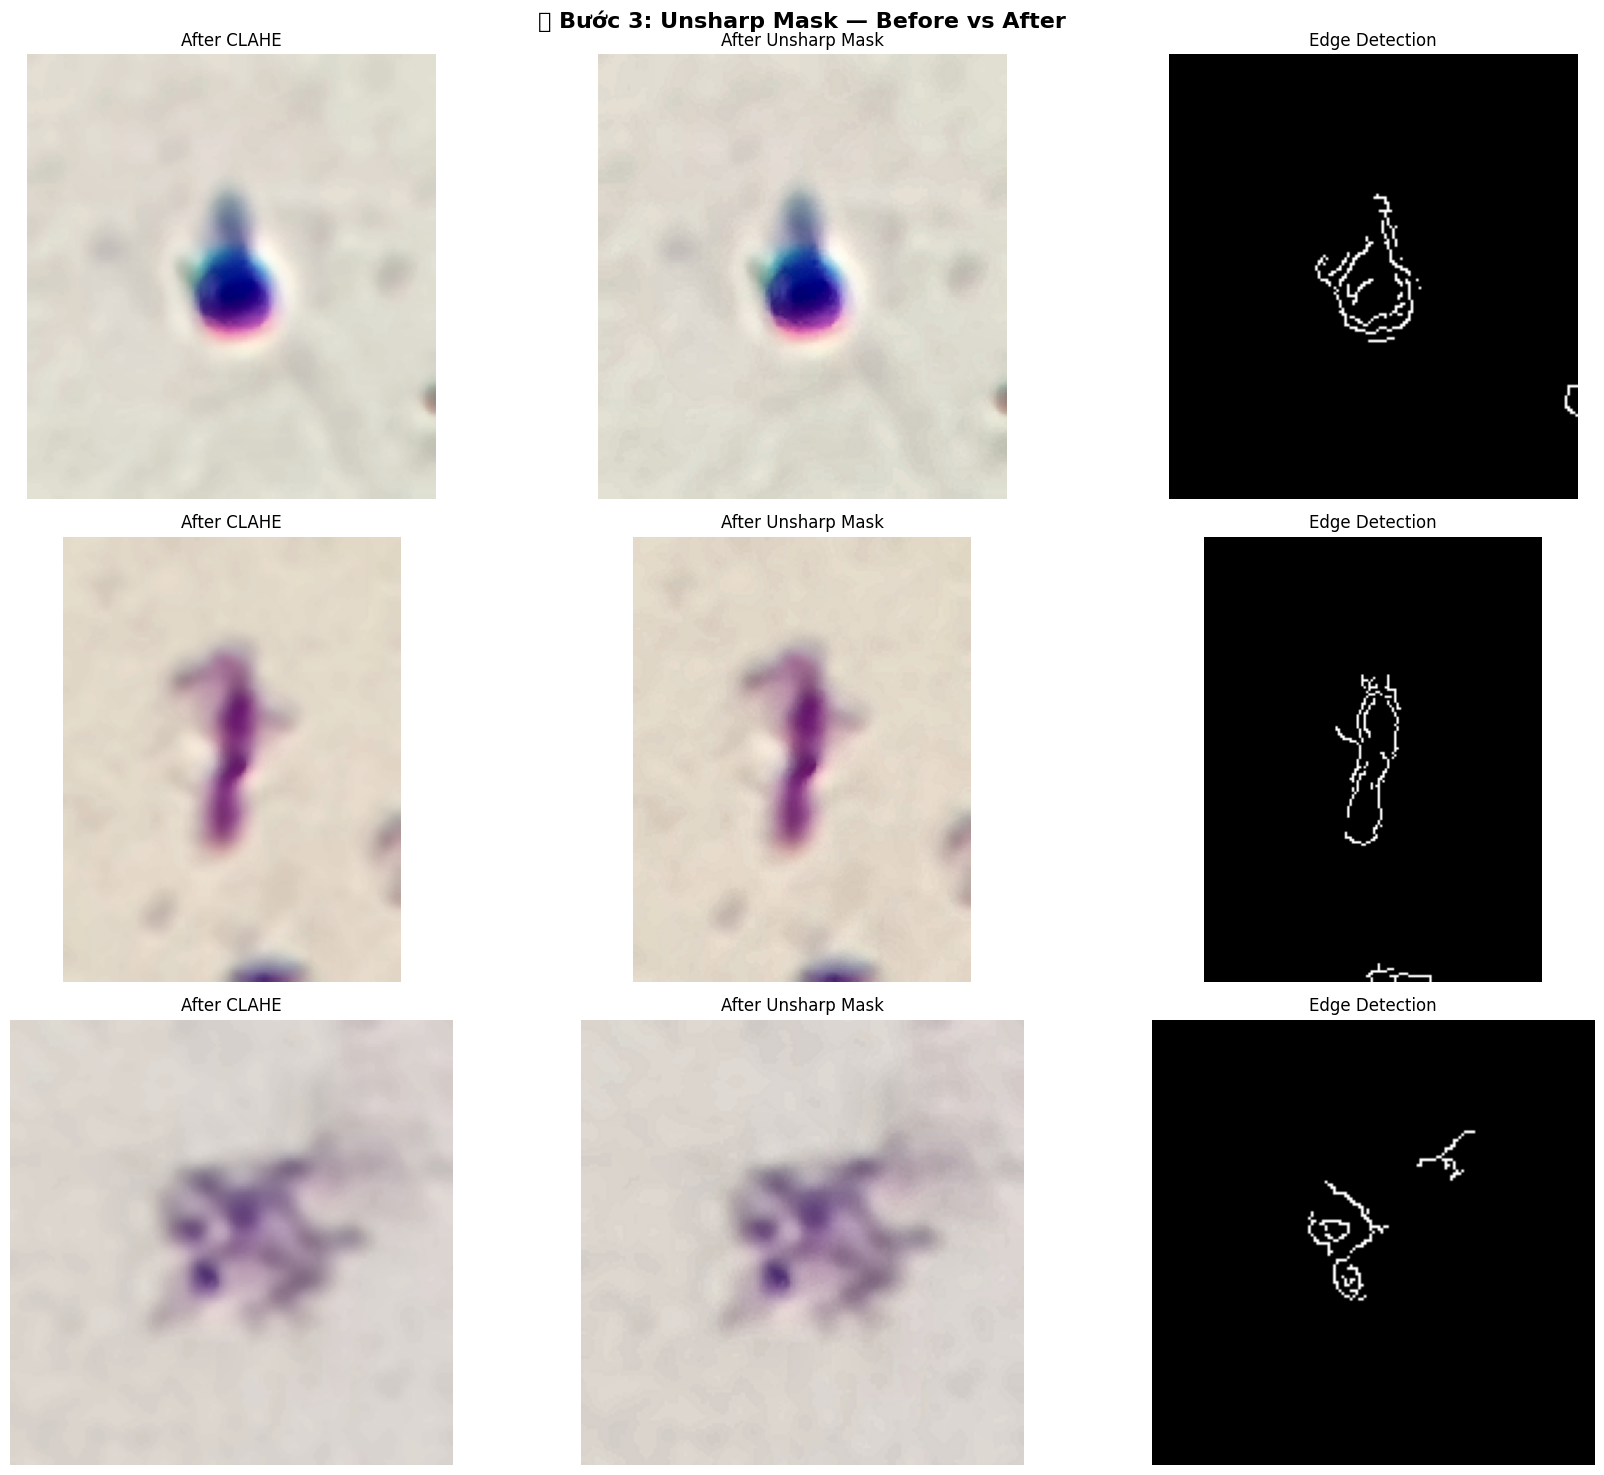

In [ ]:
# %% --- Viz: Bước 3 - Unsharp Mask Before/After ---
if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 3, figsize=(18, 5*len(sample_paths)))
    fig.suptitle('🔍 Bước 3: Unsharp Mask — Before vs After', fontsize=16, fontweight='bold')
    if len(sample_paths) == 1: axes = axes.reshape(1, -1)
    for i, p in enumerate(sample_paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        clahe_img = apply_clahe(denoise_bilateral(img))
        sharpened = sharpen_unsharp(clahe_img)
        edges = cv2.Canny(cv2.cvtColor(sharpened, cv2.COLOR_RGB2GRAY), 50, 150)
        axes[i,0].imshow(clahe_img); axes[i,0].set_title('After CLAHE')
        axes[i,1].imshow(sharpened); axes[i,1].set_title('After Unsharp Mask')
        axes[i,2].imshow(edges, cmap='gray'); axes[i,2].set_title('Edge Detection')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_03_sharpen.png", dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2103/2640181744.py:16: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2103/2640181744.py:17: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_full_pipeline.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


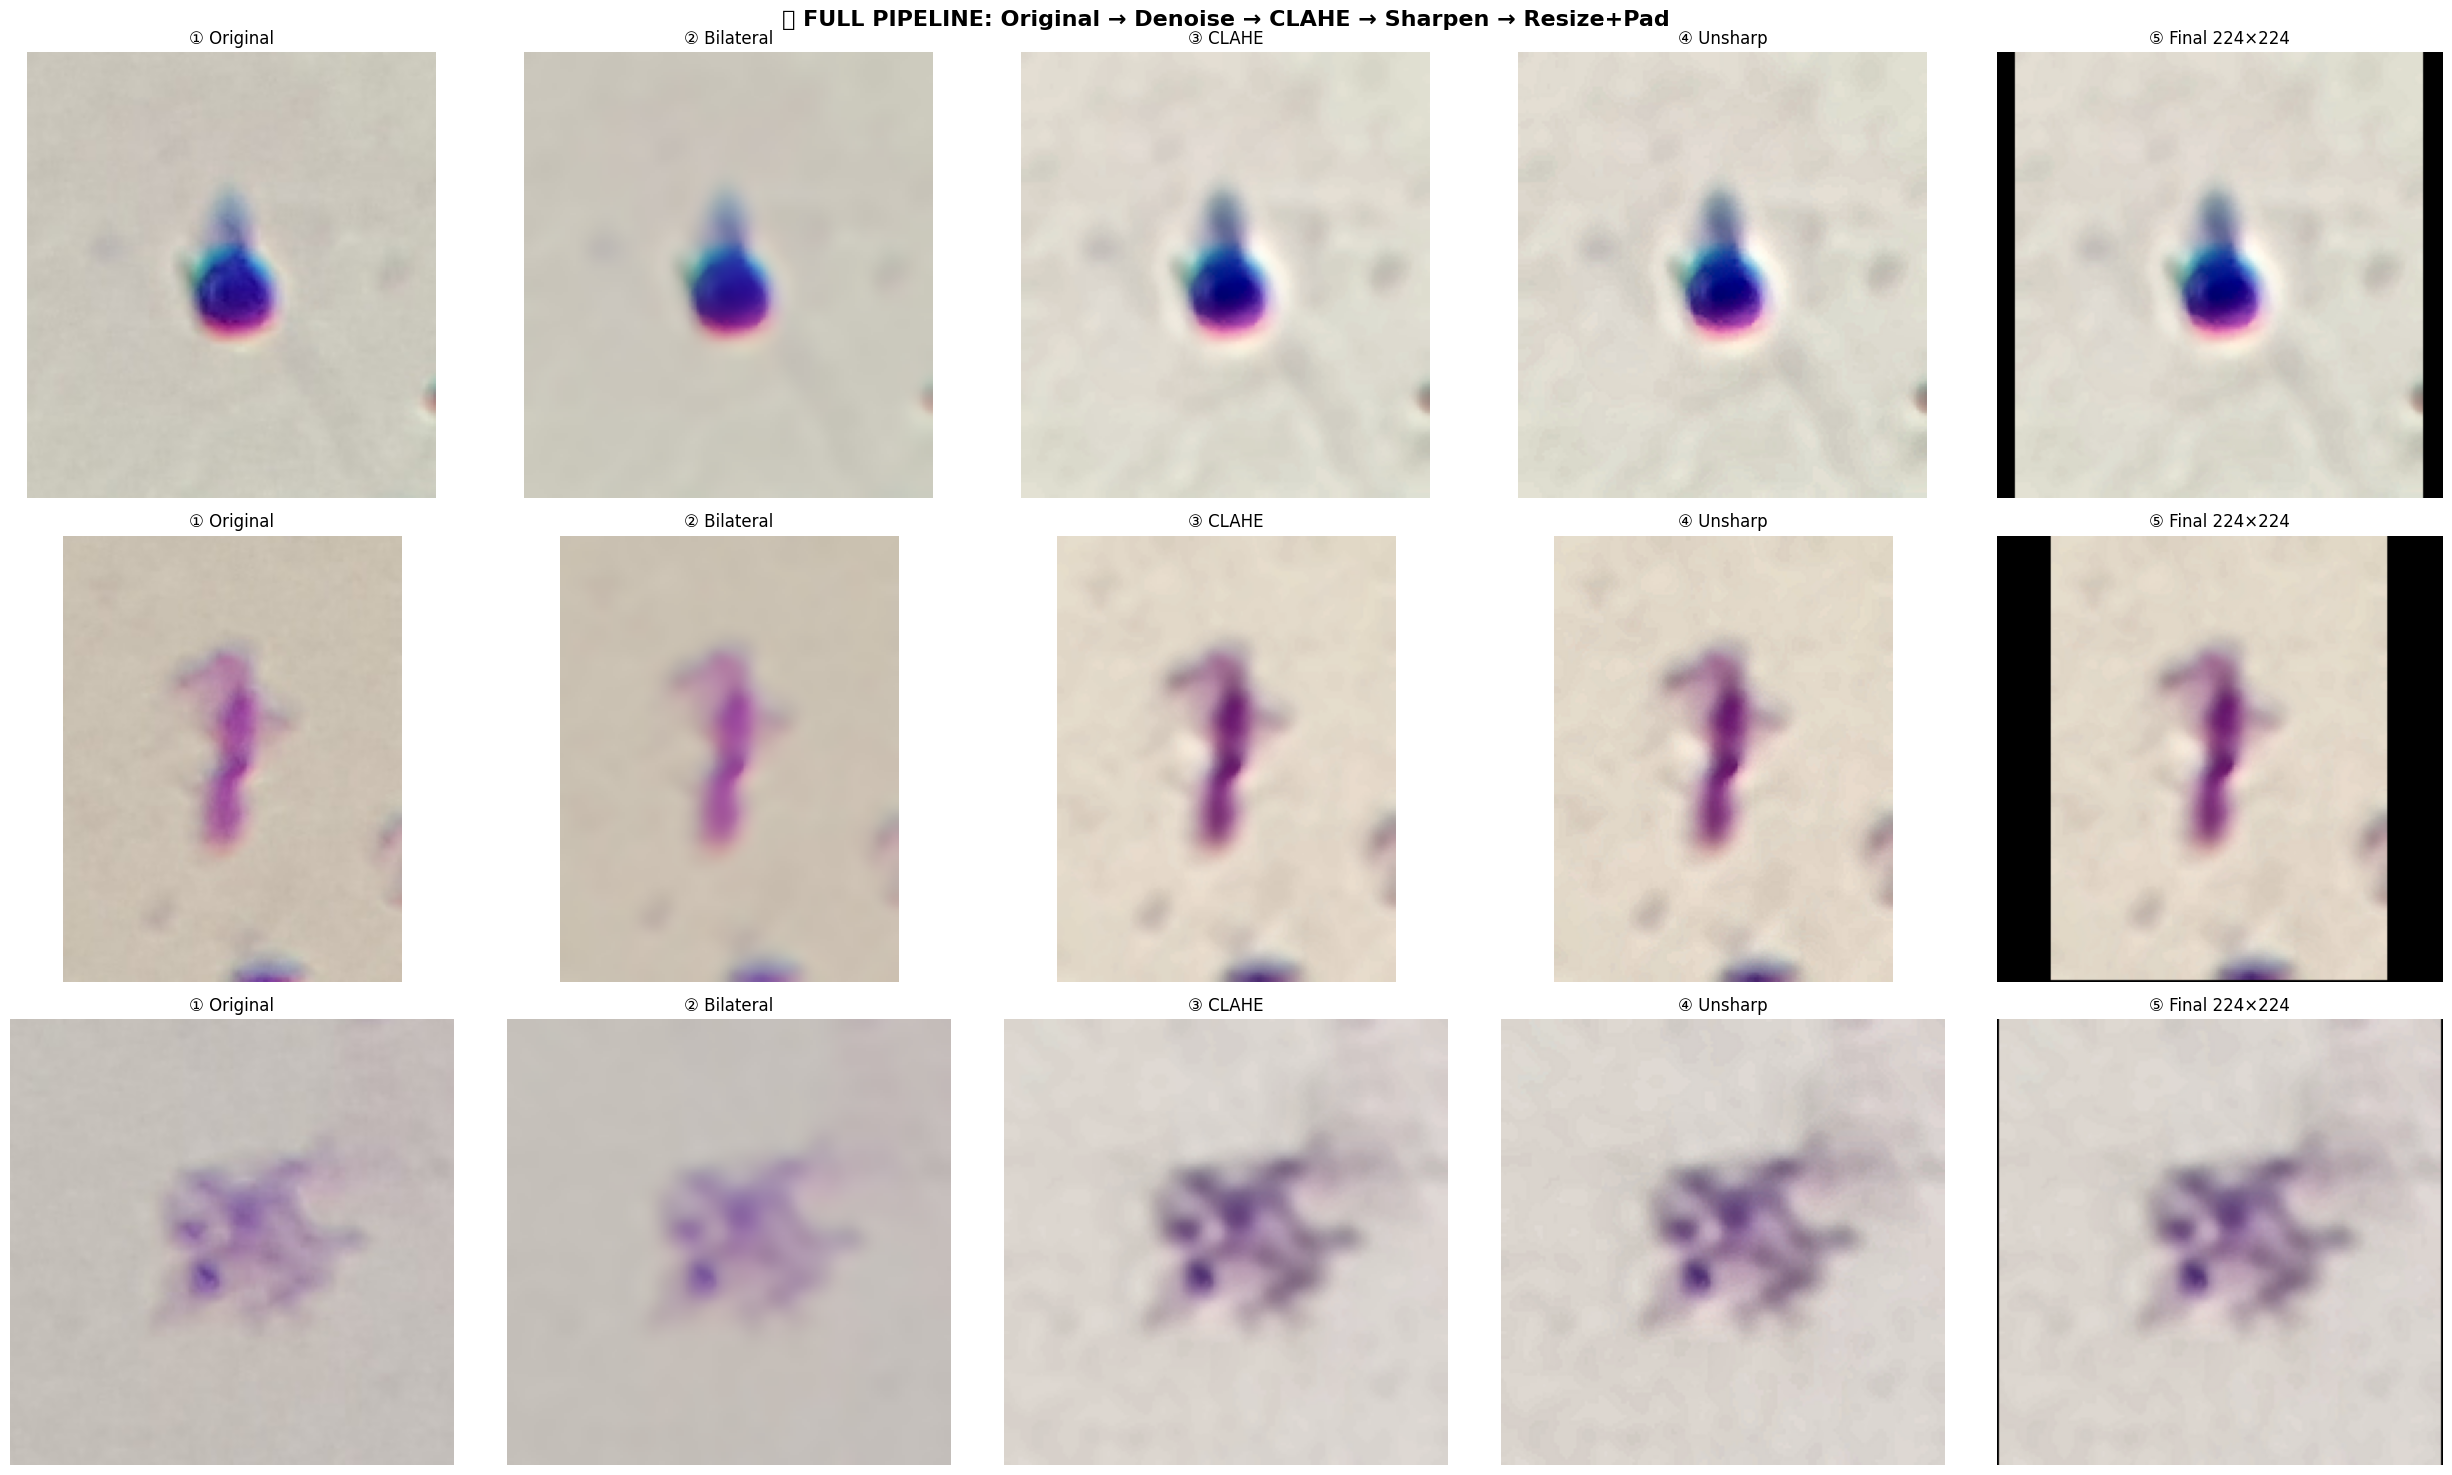

In [ ]:
# %% --- Viz: Full Preprocessing Pipeline Comparison ---
if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 5, figsize=(25, 5*len(sample_paths)))
    fig.suptitle('🔬 FULL PIPELINE: Original → Denoise → CLAHE → Sharpen → Resize+Pad',
                 fontsize=16, fontweight='bold')
    if len(sample_paths) == 1: axes = axes.reshape(1, -1)
    titles = ['① Original', '② Bilateral', '③ CLAHE', '④ Unsharp', '⑤ Final 224×224']
    for i, p in enumerate(sample_paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        s1 = denoise_bilateral(img)
        s2 = apply_clahe(s1)
        s3 = sharpen_unsharp(s2)
        s4 = resize_with_padding(s3, CONFIG.IMAGE_SIZE)
        for j, (data, title) in enumerate(zip([img,s1,s2,s3,s4], titles)):
            axes[i,j].imshow(data); axes[i,j].set_title(title); axes[i,j].axis('off')
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/prep_full_pipeline.png", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# %% --- Cell 4b: Auto-detect Class Folders ---
def detect_class_folders(data_dir):
    """Tự động phát hiện và map tên thư mục class trong dataset."""
    data_path = Path(data_dir)
    if not data_path.exists():
        return {n: n for n in CONFIG.CLASS_NAMES}
    found = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
    if not found:
        return {n: n for n in CONFIG.CLASS_NAMES}
    PATTERNS = {
        "Normal_Sperm":   ["normal_sperm", "normal", "normalsperm"],
        "Abnormal_Sperm": ["abnormal_sperm", "abnormal", "abnormalsperm"],
        "Non_Sperm":      ["non_sperm", "non-sperm", "nonsperm", "non sperm", "nosperm"],
    }
    mapping = {}  # folder_name → standard_class_name
    for folder in found:
        norm = folder.lower().replace("-", "_").replace(" ", "_").strip()
        for std_name, pats in PATTERNS.items():
            if norm == std_name.lower() or norm in pats:
                mapping[folder] = std_name; break
        if folder not in mapping:
            mapping[folder] = folder  # Giữ nguyên nếu không match
    print(f"📂 Thư mục tìm thấy: {found}")
    print(f"🔗 Mapping: {mapping}")
    return mapping

In [ ]:
# %% --- Cell 5: Split & Preprocess Dataset ---
def split_and_preprocess(raw_dir, out_dir, size=224, seed=42):
    """Đọc raw → auto-detect folders → preprocess → split 70/15/15 → lưu."""
    folder_map = detect_class_folders(raw_dir)
    images, labels = [], []
    for folder, std_class in folder_map.items():
        d = Path(raw_dir) / folder
        if not d.exists(): print(f"⚠️ Missing: {d}"); continue
        count = 0
        for p in sorted(d.glob("*")):
            if p.suffix.lower() in [".png",".jpg",".jpeg",".bmp",".tif"]:
                images.append(str(p)); labels.append(std_class); count += 1
        print(f"  📁 {folder} → {std_class}: {count} ảnh")
    print(f"\n📊 Tổng: {len(images)} ảnh | {Counter(labels)}")
    # Kiểm tra đủ 3 class
    found_classes = set(labels)
    missing = set(CONFIG.CLASS_NAMES) - found_classes
    if missing:
        print(f"❌ THIẾU CLASS: {missing} — Kiểm tra tên thư mục!")

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(images, labels, test_size=0.3, stratify=labels, random_state=seed)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=seed)

    for split, (X, y) in {"train":(X_tr,y_tr),"val":(X_val,y_val),"test":(X_te,y_te)}.items():
        print(f"🔄 {split}: {len(X)} ảnh")
        for img_path, lbl in tqdm(zip(X, y), total=len(X)):
            save_dir = Path(out_dir)/split/lbl; save_dir.mkdir(parents=True, exist_ok=True)
            save_path = save_dir / Path(img_path).name
            if save_path.exists(): continue
            try:
                proc = preprocess_image(img_path, size)
                cv2.imwrite(str(save_path), cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))
            except Exception as e: print(f"  ❌ {e}")
    print("✅ Done!")


In [ ]:
split_and_preprocess(CONFIG.RAW_DATA_DIR, CONFIG.PROCESSED_DIR, CONFIG.IMAGE_SIZE)

📂 Thư mục tìm thấy: ['Abnormal_Sperm', 'Non-Sperm', 'Normal_Sperm']
🔗 Mapping: {'Abnormal_Sperm': 'Abnormal_Sperm', 'Non-Sperm': 'Non_Sperm', 'Normal_Sperm': 'Normal_Sperm'}
  📁 Abnormal_Sperm → Abnormal_Sperm: 1005 ảnh
  📁 Non-Sperm → Non_Sperm: 974 ảnh
  📁 Normal_Sperm → Normal_Sperm: 1021 ảnh

📊 Tổng: 3000 ảnh | Counter({'Normal_Sperm': 1021, 'Abnormal_Sperm': 1005, 'Non_Sperm': 974})
🔄 train: 2100 ảnh


  0%|          | 0/2100 [00:00<?, ?it/s]

🔄 val: 450 ảnh


  0%|          | 0/450 [00:00<?, ?it/s]

🔄 test: 450 ảnh


  0%|          | 0/450 [00:00<?, ?it/s]

✅ Done!


In [ ]:
# %% --- Cell 6: Augmentation & DataLoader ---
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(CONFIG.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(CONFIG.IMAGENET_MEAN, CONFIG.IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.15)),
])
val_transforms = transforms.Compose([
    transforms.Resize((CONFIG.IMAGE_SIZE, CONFIG.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CONFIG.IMAGENET_MEAN, CONFIG.IMAGENET_STD),
])

class SpermDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.images, self.labels = [], []
        self.class_to_idx = {n: i for i, n in enumerate(CONFIG.CLASS_NAMES)}
        root_path = Path(root_dir)
        if not root_path.exists():
            print(f"⚠️ Thư mục không tồn tại: {root_dir}")
            return
        # Auto-detect folders và map về class chuẩn
        folder_map = detect_class_folders(root_dir)
        for folder, std_class in folder_map.items():
            d = root_path / folder
            if std_class not in self.class_to_idx:
                print(f"⚠️ '{std_class}' (folder '{folder}') không trong CLASS_NAMES")
                continue
            idx = self.class_to_idx[std_class]
            for p in sorted(d.glob("*")):
                if p.suffix.lower() in [".png",".jpg",".jpeg",".bmp",".tif"]:
                    self.images.append(p); self.labels.append(idx)
        # Report
        lc = Counter(self.labels)
        for name, i in self.class_to_idx.items():
            c = lc.get(i, 0)
            status = "✅" if c > 0 else "❌"
            print(f"   {status} {name}: {c} ảnh")
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def create_dataloaders():
    print("\n" + "="*50 + "\n📂 LOADING DATASETS\n" + "="*50)
    train_ds = SpermDataset(f"{CONFIG.PROCESSED_DIR}/train", train_transforms)
    val_ds   = SpermDataset(f"{CONFIG.PROCESSED_DIR}/val",   val_transforms)
    test_ds  = SpermDataset(f"{CONFIG.PROCESSED_DIR}/test",  val_transforms)

    # Validate đủ 3 class
    train_counts = Counter(train_ds.labels)
    missing = [CONFIG.CLASS_NAMES[i] for i in range(CONFIG.NUM_CLASSES)
               if train_counts.get(i, 0) == 0]
    if missing:
        print(f"\n❌❌❌ CRITICAL: Class không có data: {missing}")
        print(f"   → Model KHÔNG THỂ học các class này!")
        print(f"   → Kiểm tra lại tên thư mục trong '{CONFIG.RAW_DATA_DIR}'")

    # WeightedRandomSampler
    total = len(train_ds.labels)
    cw = {c: total/n for c, n in train_counts.items() if n > 0}
    sampler = WeightedRandomSampler(
        [cw.get(l, 1.0) for l in train_ds.labels], num_samples=total
    )

    # Class weights cho loss
    wt = torch.tensor(
        [total / (CONFIG.NUM_CLASSES * max(train_counts.get(i, 0), 1))
         for i in range(CONFIG.NUM_CLASSES)],
        dtype=torch.float32
    )
    wt = wt / wt.sum() * CONFIG.NUM_CLASSES

    kw = dict(num_workers=CONFIG.NUM_WORKERS, pin_memory=True)
    tl = DataLoader(train_ds, batch_size=CONFIG.BATCH_SIZE, sampler=sampler, drop_last=True, **kw)
    vl = DataLoader(val_ds,   batch_size=CONFIG.BATCH_SIZE, shuffle=False, **kw)
    tel= DataLoader(test_ds,  batch_size=CONFIG.BATCH_SIZE, shuffle=False, **kw)
    print(f"\n✅ Train:{len(train_ds)} | Val:{len(val_ds)} | Test:{len(test_ds)}")
    print(f"   Class weights: {wt.numpy()}")
    return tl, vl, tel, wt


In [ ]:

# === TẠO DATALOADERS ===
train_loader, val_loader, test_loader, class_weights = create_dataloaders()



📂 LOADING DATASETS
📂 Thư mục tìm thấy: ['Abnormal_Sperm', 'Non_Sperm', 'Normal_Sperm']
🔗 Mapping: {'Abnormal_Sperm': 'Abnormal_Sperm', 'Non_Sperm': 'Non_Sperm', 'Normal_Sperm': 'Normal_Sperm'}
   ✅ Normal_Sperm: 715 ảnh
   ✅ Abnormal_Sperm: 703 ảnh
   ✅ Non_Sperm: 682 ảnh
📂 Thư mục tìm thấy: ['Abnormal_Sperm', 'Non_Sperm', 'Normal_Sperm']
🔗 Mapping: {'Abnormal_Sperm': 'Abnormal_Sperm', 'Non_Sperm': 'Non_Sperm', 'Normal_Sperm': 'Normal_Sperm'}
   ✅ Normal_Sperm: 153 ảnh
   ✅ Abnormal_Sperm: 151 ảnh
   ✅ Non_Sperm: 146 ảnh
📂 Thư mục tìm thấy: ['Abnormal_Sperm', 'Non_Sperm', 'Normal_Sperm']
🔗 Mapping: {'Abnormal_Sperm': 'Abnormal_Sperm', 'Non_Sperm': 'Non_Sperm', 'Normal_Sperm': 'Normal_Sperm'}
   ✅ Normal_Sperm: 153 ảnh
   ✅ Abnormal_Sperm: 151 ảnh
   ✅ Non_Sperm: 146 ảnh

✅ Train:2100 | Val:450 | Test:450
   Class weights: [0.978647  0.9953522 1.026001 ]


In [ ]:
# %% --- Cell: Model EfficientNetV2-S + CBAM ---
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False))
    def forward(self, x):
        B, C, _, _ = x.size()
        avg_out = self.mlp(self.avg_pool(x).view(B, C))
        max_out = self.mlp(self.max_pool(x).view(B, C))
        return x * torch.sigmoid(avg_out + max_out).view(B, C, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        return x * torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(kernel_size)
    def forward(self, x):
        return self.spatial_attn(self.channel_attn(x))

class SpermClassifier(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        # === EfficientNetV2-S (Top-1: 84.2%, 21.5M params) ===
        self.backbone = models.efficientnet_v2_s(
            weights='IMAGENET1K_V1' if pretrained else None)
        # V2-S output channels = 1280
        self.cbam = CBAM(channels=1280, reduction=16)
        self.backbone.classifier = nn.Identity()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(1280, 256), nn.BatchNorm1d(256),
            nn.ReLU(True), nn.Dropout(0.2), nn.Linear(256, num_classes))
        for p in self.backbone.parameters(): p.requires_grad = False

    def forward(self, x):
        features = self.cbam(self.backbone.features(x))
        return self.head(self.pool(features).flatten(1))

    def extract_multi_layer_features(self, x):
        """Trích xuất features từ nhiều layers cho t-SNE."""
        feats = {}
        out = x
        for i, layer in enumerate(self.backbone.features):
            out = layer(out)
            if i in [2, 4, 6]:  # Early, Mid, Late stages
                feats[f'stage_{i}'] = self.pool(out).flatten(1).detach()
        # After CBAM
        cbam_out = self.cbam(out)
        feats['cbam_features'] = self.pool(cbam_out).flatten(1).detach()
        return feats

    def unfreeze_last_blocks(self):
        for p in self.backbone.features[-3:].parameters(): p.requires_grad = True
        print("🔓 Last 3 blocks unfrozen")

    def unfreeze_all(self):
        for p in self.backbone.parameters(): p.requires_grad = True
        print("🔓 All unfrozen")

    def count_params(self):
        t = sum(p.numel() for p in self.parameters())
        tr = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"📊 {tr:,} trainable / {t:,} total ({100*tr/t:.1f}%)")

print("✅ Model: EfficientNetV2-S + CBAM defined")

✅ Model: EfficientNetV2-S + CBAM defined


In [ ]:
# %% --- Cell 7b: Khởi tạo Model ---
model = SpermClassifier().to(DEVICE)
model.count_params()

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 142MB/s]


📊 534,117 trainable / 20,711,605 total (2.6%)


In [ ]:
# %% --- Cell 7c: Auto-detect Checkpoints đã train ---
def detect_existing_checkpoints():
    """Quét thư mục checkpoints, phân biệt stage ĐÃ XONG vs ĐANG DỞ.
    Trả về:
        stage_status: dict {stage_name: {'status': 'completed'|'in_progress'|'not_started',
                                          'path': checkpoint_path, 'epoch': last_epoch,
                                          'total_epochs': planned_epochs}}
        has_final: bool — final_model.pth có tồn tại không
    """
    print("\n" + "="*60)
    print("🔍 AUTO-DETECT: Kiểm tra checkpoints đã train")
    print("="*60)

    ckpt_dir = CONFIG.CHECKPOINT_DIR
    stage_names  = ["stage1_head", "stage2_last_blocks", "stage3_full"]
    stage_epochs = dict(zip(stage_names, CONFIG.EPOCHS))  # planned epochs mỗi stage
    stage_status = {}  # kết quả trả về

    # --- Kiểm tra final model ---
    final_path = os.path.join(ckpt_dir, "final_model.pth")
    has_final = os.path.exists(final_path)
    if has_final:
        size_mb = os.path.getsize(final_path) / (1024*1024)
        print(f"\n🏁 final_model.pth  → ✅ ĐÃ CÓ ({size_mb:.1f} MB)")
        print(f"   → Training đã hoàn tất! Không cần train lại.")
    else:
        print(f"\n🏁 final_model.pth  → ❌ Chưa có")

    # --- Kiểm tra từng stage ---
    print()
    for sname in stage_names:
        planned = stage_epochs[sname]
        latest_path = os.path.join(ckpt_dir, f"{sname}_latest.pth")
        best_path   = os.path.join(ckpt_dir, f"{sname}_best.pth")
        has_latest = os.path.exists(latest_path)
        has_best   = os.path.exists(best_path)

        if has_latest:
            ck = torch.load(latest_path, map_location="cpu")
            last_ep    = ck.get('epoch', 0)           # 0-indexed
            total_ep   = ck.get('total_epochs', None)  # nếu checkpoint cũ chưa có field này
            is_done    = ck.get('completed', False)
            vl_latest  = ck.get('vl', 0)
            va_latest  = ck.get('va', 0)

            # Heuristic: nếu checkpoint cũ (chưa có 'completed'), dùng epoch so với planned
            if total_ep is None:
                total_ep = planned
                is_done = (last_ep + 1) >= planned  # epoch 0-indexed

            if is_done:
                # --- HOÀN THÀNH ---
                status = "completed"
                resume_path = best_path if has_best else latest_path
                ck_best = torch.load(resume_path, map_location="cpu") if has_best else ck
                print(f"   ✅ {sname}: HOÀN THÀNH — epoch {last_ep+1}/{total_ep}, "
                      f"best_val_loss={ck_best.get('vl',0):.4f}, best_val_acc={ck_best.get('va',0):.2f}%")
                stage_status[sname] = {
                    'status': 'completed', 'path': resume_path,
                    'epoch': last_ep, 'total_epochs': total_ep
                }
            else:
                # --- ĐANG DỞ → cần resume ---
                status = "in_progress"
                remaining = total_ep - (last_ep + 1)
                print(f"   🔄 {sname}: ĐANG DỞ — epoch {last_ep+1}/{total_ep} "
                      f"(còn {remaining} epoch), val_loss={vl_latest:.4f}, val_acc={va_latest:.2f}%")
                stage_status[sname] = {
                    'status': 'in_progress', 'path': latest_path,
                    'epoch': last_ep, 'total_epochs': total_ep
                }
        else:
            # --- CHƯA BẮT ĐẦU ---
            print(f"   ⬜ {sname}: CHƯA BẮT ĐẦU")
            stage_status[sname] = {
                'status': 'not_started', 'path': None,
                'epoch': -1, 'total_epochs': planned
            }

    # --- Tổng kết ---
    print("\n" + "-"*60)
    n_done = sum(1 for v in stage_status.values() if v['status'] == 'completed')
    n_prog = sum(1 for v in stage_status.values() if v['status'] == 'in_progress')
    n_new  = sum(1 for v in stage_status.values() if v['status'] == 'not_started')

    if has_final:
        print("✅ KẾT LUẬN: Model đã train xong. Chạy cell tiếp để load & evaluate.")
    elif n_done == 3:
        print("✅ KẾT LUẬN: Cả 3 stage đã xong. Sẽ lưu final_model.pth.")
    elif n_prog > 0:
        for sn, sv in stage_status.items():
            if sv['status'] == 'in_progress':
                remaining = sv['total_epochs'] - (sv['epoch'] + 1)
                print(f"🔄 KẾT LUẬN: {sn} đang dở (epoch {sv['epoch']+1}/{sv['total_epochs']}), "
                      f"sẽ RESUME thêm {remaining} epoch.")
        for sn, sv in stage_status.items():
            if sv['status'] == 'completed':
                print(f"   ⏭️  {sn}: Sẽ SKIP (đã hoàn thành)")
            elif sv['status'] == 'not_started':
                print(f"   📋 {sn}: Sẽ train từ đầu")
    else:
        print("📋 KẾT LUẬN: Chưa train gì. Sẽ bắt đầu từ đầu.")
    print("="*60)

    return stage_status, has_final

def load_final_model(model):
    """Load final_model.pth nếu có. Trả về True nếu load thành công."""
    final_path = os.path.join(CONFIG.CHECKPOINT_DIR, "final_model.pth")
    if os.path.exists(final_path):
        model.load_state_dict(torch.load(final_path, map_location=DEVICE))
        model.eval()
        print(f"✅ Đã load model từ: {final_path}")
        print(f"   → Sẵn sàng evaluate / inference. Không cần train lại!")
        return True
    return False

# === CHẠY DETECT ===
completed_stages, has_final_model = detect_existing_checkpoints()
if has_final_model:
    model = SpermClassifier().to(DEVICE)
    load_final_model(model)
else:
    model = SpermClassifier().to(DEVICE)
    model.count_params()



🔍 AUTO-DETECT: Kiểm tra checkpoints đã train

🏁 final_model.pth  → ❌ Chưa có

   ✅ stage1_head: HOÀN THÀNH — epoch 10/10, best_val_loss=0.7518, best_val_acc=71.56%
   🔄 stage2_last_blocks: ĐANG DỞ — epoch 2/15 (còn 13 epoch), val_loss=0.6028, val_acc=81.78%
   ⬜ stage3_full: CHƯA BẮT ĐẦU

------------------------------------------------------------
🔄 KẾT LUẬN: stage2_last_blocks đang dở (epoch 2/15), sẽ RESUME thêm 13 epoch.
   ⏭️  stage1_head: Sẽ SKIP (đã hoàn thành)
   📋 stage3_full: Sẽ train từ đầu
📊 534,117 trainable / 20,711,605 total (2.6%)


In [ ]:
# %% --- Cell 8: Training Functions ---
def save_ckpt(model, opt, epoch, vl, va, path, total_epochs=None, completed=False):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'epoch': epoch, 'model': model.state_dict(), 'opt': opt.state_dict(),
        'vl': vl, 'va': va, 'total_epochs': total_epochs, 'completed': completed
    }, path)

def load_ckpt(model, opt, path):
    ck = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    if opt: opt.load_state_dict(ck['opt'])
    print(f"✅ Loaded epoch {ck['epoch']}, val_loss={ck['vl']:.4f}, val_acc={ck['va']:.2f}%")
    return ck['epoch']+1, ck['vl']

def train_one_epoch(model, loader, crit, opt, scaler, accum=2):
    model.train(); rl, cor, tot = 0., 0, 0; opt.zero_grad()
    for i, (imgs, labs) in enumerate(loader):
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):
            out = model(imgs); loss = crit(out, labs) / accum
        scaler.scale(loss).backward()
        if (i+1) % accum == 0 or (i+1) == len(loader):
            scaler.step(opt); scaler.update(); opt.zero_grad()
        rl += loss.item()*accum*imgs.size(0); _, pred = out.max(1)
        tot += labs.size(0); cor += pred.eq(labs).sum().item()
    return rl/tot, 100.*cor/tot

@torch.no_grad()
def validate(model, loader, crit):
    model.eval(); rl, cor, tot = 0., 0, 0
    for imgs, labs in loader:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):
            out = model(imgs); loss = crit(out, labs)
        rl += loss.item()*imgs.size(0); _, pred = out.max(1)
        tot += labs.size(0); cor += pred.eq(labs).sum().item()
    return rl/tot, 100.*cor/tot

def train_stage(model, tl, vl, crit, lr, epochs, name, resume_from=None):
    """Train 1 stage. Nếu resume_from != None, load checkpoint và tiếp tục từ epoch đã lưu."""
    start_ep = 0
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=CONFIG.WEIGHT_DECAY)

    # --- Resume nếu có checkpoint ---
    if resume_from and os.path.exists(resume_from):
        start_ep, _ = load_ckpt(model, opt, resume_from)
        print(f"🔄 RESUME {name} từ epoch {start_ep}/{epochs}")
        remaining = epochs - start_ep
        if remaining <= 0:
            print(f"   ⏭️  Đã đủ {epochs} epoch, không cần train thêm.")
            bp = f"{CONFIG.CHECKPOINT_DIR}/{name}_best.pth"
            if os.path.exists(bp): load_ckpt(model, None, bp)
            return {'tl':[],'ta':[],'vl':[],'va':[]}
    else:
        remaining = epochs

    print(f"\n{'='*55}")
    print(f"🚀 {name} | LR={lr} | Epochs {start_ep+1}→{epochs} (còn {remaining} epoch)")
    print(f"{'='*55}")
    model.count_params()

    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG.USE_AMP)
    es = EarlyStopping(CONFIG.PATIENCE)
    hist = {'tl':[],'ta':[],'vl':[],'va':[]}; best = float('inf')

    # Load best val_loss hiện có để so sánh
    bp = f"{CONFIG.CHECKPOINT_DIR}/{name}_best.pth"
    if os.path.exists(bp):
        ck_best = torch.load(bp, map_location="cpu")
        best = ck_best.get('vl', float('inf'))
        print(f"   📊 Best val_loss hiện tại: {best:.4f}")

    for ep in range(start_ep, epochs):
        tls, tas = train_one_epoch(model, tl, crit, opt, scaler, CONFIG.GRAD_ACCUM_STEPS)
        vls, vas = validate(model, vl, crit)
        sched.step(vls)
        hist['tl'].append(tls); hist['ta'].append(tas)
        hist['vl'].append(vls); hist['va'].append(vas)
        print(f"  [{ep+1}/{epochs}] TrL:{tls:.4f} TrA:{tas:.1f}% | VaL:{vls:.4f} VaA:{vas:.1f}%")

        is_last = (ep + 1) >= epochs
        is_early_stop = False
        save_ckpt(model, opt, ep, vls, vas,
                  f"{CONFIG.CHECKPOINT_DIR}/{name}_latest.pth",
                  total_epochs=epochs, completed=False)
        if vls < best:
            best = vls
            save_ckpt(model, opt, ep, vls, vas,
                      f"{CONFIG.CHECKPOINT_DIR}/{name}_best.pth",
                      total_epochs=epochs, completed=False)
            print(f"  💾 Best saved (val_loss={vls:.4f})")
        es(vls)
        if es.early_stop:
            is_early_stop = True
            break

    # Đánh dấu stage hoàn thành trong latest checkpoint
    save_ckpt(model, opt, ep, vls, vas,
              f"{CONFIG.CHECKPOINT_DIR}/{name}_latest.pth",
              total_epochs=epochs, completed=True)

    if os.path.exists(bp): load_ckpt(model, None, bp)
    return hist


In [ ]:
# %% --- Cell 9: Run Full Training (with auto-detect & resume) ---
def run_training(model, tl, vl, cw, stage_status=None):
    """Train 3 stages với auto-detect:
    - Stage HOÀN THÀNH → SKIP, load best checkpoint
    - Stage ĐANG DỞ   → RESUME từ epoch cuối
    - Stage CHƯA BẮT ĐẦU → Train từ đầu
    Args:
        stage_status: dict từ detect_existing_checkpoints(), hoặc None để train tất cả.
    """
    if stage_status is None:
        stage_status = {}

    # Kiểm tra nếu final model đã có
    final_path = f"{CONFIG.CHECKPOINT_DIR}/final_model.pth"
    if os.path.exists(final_path):
        print("\n" + "="*55)
        print("🏁 final_model.pth ĐÃ TỒN TẠI — SKIP toàn bộ training!")
        print("   → Dùng load_final_model(model) để load weights.")
        print("="*55)
        model.load_state_dict(torch.load(final_path, map_location=DEVICE))
        return {}

    crit = nn.CrossEntropyLoss(weight=cw.to(DEVICE), label_smoothing=CONFIG.LABEL_SMOOTHING)
    stages = [
        ("stage1_head",   CONFIG.LRS[0], CONFIG.EPOCHS[0], lambda: None),
        ("stage2_last_blocks", CONFIG.LRS[1], CONFIG.EPOCHS[1], model.unfreeze_last_blocks),
        ("stage3_full",   CONFIG.LRS[2], CONFIG.EPOCHS[2], model.unfreeze_all),
    ]
    history = {}
    for name, lr, ep, unfreeze_fn in stages:
        unfreeze_fn()
        info = stage_status.get(name, {'status': 'not_started'})

        if info['status'] == 'completed':
            # ===== ĐÃ HOÀN THÀNH → SKIP =====
            bp = info['path']
            print(f"\n{'='*55}")
            print(f"⏭️  SKIP {name} — Đã hoàn thành! (epoch {info['epoch']+1}/{info['total_epochs']})")
            print(f"{'='*55}")
            load_ckpt(model, None, bp)
            ck = torch.load(bp, map_location="cpu")
            history[name] = {
                'tl': [ck.get('vl', 0)], 'ta': [ck.get('va', 0)],
                'vl': [ck.get('vl', 0)], 'va': [ck.get('va', 0)]
            }
            continue

        elif info['status'] == 'in_progress':
            # ===== ĐANG DỞ → RESUME =====
            resume_path = info['path']
            history[name] = train_stage(model, tl, vl, crit, lr, ep, name,
                                        resume_from=resume_path)

        else:
            # ===== CHƯA BẮT ĐẦU → Train từ đầu =====
            history[name] = train_stage(model, tl, vl, crit, lr, ep, name)

    torch.save(model.state_dict(), final_path)
    print(f"\n🏁 Done! Saved: {final_path}")
    return history

# === BẮT ĐẦU TRAINING (with auto-detect & resume) ===
stage_status, has_final = detect_existing_checkpoints()
if not has_final:
    all_history = run_training(model, train_loader, val_loader, class_weights, stage_status)
else:
    load_final_model(model)
    all_history = {}



🔍 AUTO-DETECT: Kiểm tra checkpoints đã train

🏁 final_model.pth  → ❌ Chưa có

   ✅ stage1_head: HOÀN THÀNH — epoch 10/10, best_val_loss=0.7518, best_val_acc=71.56%
   🔄 stage2_last_blocks: ĐANG DỞ — epoch 2/15 (còn 13 epoch), val_loss=0.6028, val_acc=81.78%
   ⬜ stage3_full: CHƯA BẮT ĐẦU

------------------------------------------------------------
🔄 KẾT LUẬN: stage2_last_blocks đang dở (epoch 2/15), sẽ RESUME thêm 13 epoch.
   ⏭️  stage1_head: Sẽ SKIP (đã hoàn thành)
   📋 stage3_full: Sẽ train từ đầu

⏭️  SKIP stage1_head — Đã hoàn thành! (epoch 10/10)
✅ Loaded epoch 4, val_loss=0.7518, val_acc=71.56%
🔓 Last 3 blocks unfrozen
✅ Loaded epoch 1, val_loss=0.6028, val_acc=81.78%
🔄 RESUME stage2_last_blocks từ epoch 2/15

🚀 stage2_last_blocks | LR=0.0001 | Epochs 3→15 (còn 13 epoch)
📊 18,890,029 trainable / 20,711,605 total (91.2%)


/tmp/ipykernel_2103/3460124954.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG.USE_AMP)
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


   📊 Best val_loss hiện tại: 0.6028


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2103/3460124954.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
/tmp/ipykernel_2103/3460124954.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):


  [3/15] TrL:0.5592 TrA:85.7% | VaL:0.5735 VaA:84.9%
  💾 Best saved (val_loss=0.5735)
  [4/15] TrL:0.5416 TrA:86.3% | VaL:0.5589 VaA:84.0%
  💾 Best saved (val_loss=0.5589)
  [5/15] TrL:0.5156 TrA:88.5% | VaL:0.5594 VaA:84.2%
  [6/15] TrL:0.3989 TrA:96.1% | VaL:0.5599 VaA:83.8%
  [7/15] TrL:0.3555 TrA:98.6% | VaL:0.5545 VaA:84.4%
  💾 Best saved (val_loss=0.5545)
  [8/15] TrL:0.5395 TrA:86.9% | VaL:0.5513 VaA:86.4%
  💾 Best saved (val_loss=0.5513)
  [9/15] TrL:0.5232 TrA:87.1% | VaL:0.5570 VaA:85.1%
  [10/15] TrL:0.4942 TrA:89.5% | VaL:0.5250 VaA:87.6%
  💾 Best saved (val_loss=0.5250)
  [11/15] TrL:0.5121 TrA:87.8% | VaL:0.5395 VaA:86.7%
  [12/15] TrL:0.4609 TrA:91.4% | VaL:0.5281 VaA:87.3%
  [13/15] TrL:0.4695 TrA:90.9% | VaL:0.5629 VaA:86.7%
  [14/15] TrL:0.4635 TrA:91.3% | VaL:0.5667 VaA:83.8%
  [15/15] TrL:0.4485 TrA:92.4% | VaL:0.5597 VaA:84.7%
✅ Loaded epoch 9, val_loss=0.5250, val_acc=87.56%
🔓 All unfrozen

🚀 stage3_full | LR=1e-05 | Epochs 1→12 (còn 12 epoch)
📊 20,711,605 trainab

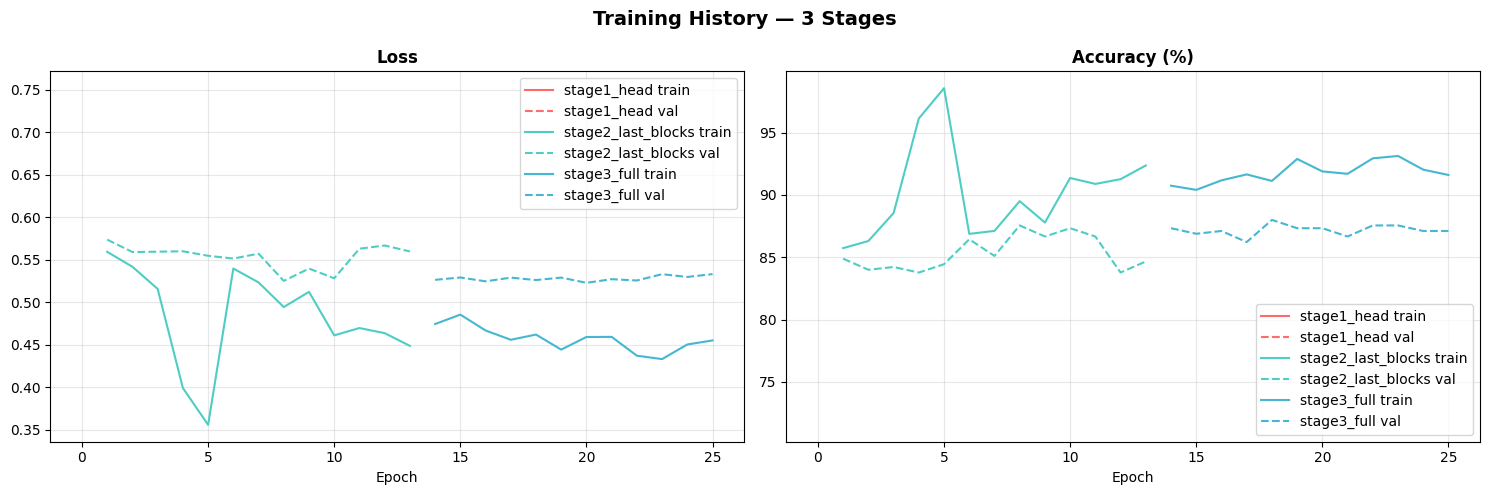

In [ ]:
import matplotlib.pyplot as plt

# %% --- Cell 10: Plot Training Curves ---
def plot_history(hist):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    colors = {'stage1_head':'#FF6B6B','stage2_last_blocks':'#4ECDC4','stage3_full':'#45B7D1'}
    off = 0
    for s, h in hist.items():
        ep = range(off, off+len(h['tl']))
        ax[0].plot(ep, h['tl'], '-',  color=colors[s], label=f'{s} train')
        ax[0].plot(ep, h['vl'], '--', color=colors[s], label=f'{s} val')
        ax[1].plot(ep, h['ta'], '-',  color=colors[s], label=f'{s} train')
        ax[1].plot(ep, h['va'], '--', color=colors[s], label=f'{s} val')
        off += len(h['tl'])
    for a, t in zip(ax, ['Loss','Accuracy (%)']):
        a.set_title(t, fontweight='bold'); a.set_xlabel('Epoch'); a.legend(); a.grid(alpha=0.3)
    plt.suptitle('Training History — 3 Stages', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history(all_history)


In [ ]:
# %% --- Cell 11: Evaluate on Test Set ---
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, lbls, probs = [], [], []
    for imgs, labs in tqdm(loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):
            out = model(imgs)
        pr = F.softmax(out, dim=1)
        preds.extend(out.argmax(1).cpu().numpy())
        lbls.extend(labs.numpy()); probs.extend(pr.cpu().numpy())
    preds, lbls, probs = np.array(preds), np.array(lbls), np.array(probs)

    # --- Classification Report ---
    print("\n" + "="*60 + "\n📊 CLASSIFICATION REPORT\n" + "="*60)
    print(classification_report(lbls, preds, target_names=CONFIG.CLASS_NAMES, digits=4))

    # --- Per-class Metrics ---
    cm = confusion_matrix(lbls, preds)
    n_classes = len(CONFIG.CLASS_NAMES)
    overall_acc = 100 * np.mean(preds == lbls)

    print("="*60)
    print("📋 CHI TIẾT METRICS TỪNG LỚP")
    print("="*60)
    print(f"{'Lớp':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'Specificity':>12} {'F1-Score':>10}")
    print("-"*72)

    per_class = {}
    for i, cls in enumerate(CONFIG.CLASS_NAMES):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        acc_i   = 100 * (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn) > 0 else 0
        prec_i  = 100 * tp / (tp + fp) if (tp + fp) > 0 else 0
        rec_i   = 100 * tp / (tp + fn) if (tp + fn) > 0 else 0  # = Sensitivity
        spec_i  = 100 * tn / (tn + fp) if (tn + fp) > 0 else 0
        f1_i    = 2 * prec_i * rec_i / (prec_i + rec_i) if (prec_i + rec_i) > 0 else 0

        per_class[cls] = {
            'accuracy': acc_i, 'precision': prec_i,
            'recall': rec_i, 'specificity': spec_i, 'f1': f1_i,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
        }
        print(f"{cls:<20} {acc_i:>9.2f}% {prec_i:>9.2f}% {rec_i:>9.2f}% {spec_i:>11.2f}% {f1_i:>9.2f}%")

    # Macro & Weighted averages
    macro_prec = np.mean([v['precision'] for v in per_class.values()])
    macro_rec  = np.mean([v['recall'] for v in per_class.values()])
    macro_f1   = np.mean([v['f1'] for v in per_class.values()])
    macro_spec = np.mean([v['specificity'] for v in per_class.values()])

    print("-"*72)
    print(f"{'Macro Avg':<20} {'':>10} {macro_prec:>9.2f}% {macro_rec:>9.2f}% {macro_spec:>11.2f}% {macro_f1:>9.2f}%")
    print(f"{'Overall Accuracy':<20} {overall_acc:>9.2f}%")
    print("="*60)

    # TP/FP/FN/TN per class
    print("\n📊 CONFUSION DETAILS (TP / FP / FN / TN)")
    print("-"*60)
    for cls, v in per_class.items():
        print(f"  {cls:<20} TP={v['tp']:>4d}  FP={v['fp']:>4d}  FN={v['fn']:>4d}  TN={v['tn']:>4d}")

    return lbls, preds, probs, per_class

y_true, y_pred, y_probs, per_class = evaluate(model, test_loader)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Testing:   0%|          | 0/29 [00:00<?, ?it/s]

/tmp/ipykernel_2103/3452596091.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(



📊 CLASSIFICATION REPORT
                precision    recall  f1-score   support

  Normal_Sperm     0.8766    0.8824    0.8795       153
Abnormal_Sperm     0.8618    0.8675    0.8647       151
     Non_Sperm     0.9861    0.9726    0.9793       146

      accuracy                         0.9067       450
     macro avg     0.9082    0.9075    0.9078       450
  weighted avg     0.9072    0.9067    0.9069       450

📋 CHI TIẾT METRICS TỪNG LỚP
Lớp                    Accuracy  Precision     Recall  Specificity   F1-Score
------------------------------------------------------------------------
Normal_Sperm             91.78%     87.66%     88.24%       93.60%     87.95%
Abnormal_Sperm           90.89%     86.18%     86.75%       92.98%     86.47%
Non_Sperm                98.67%     98.61%     97.26%       99.34%     97.93%
------------------------------------------------------------------------
Macro Avg                           90.82%     90.75%       95.31%     90.78%
Overall Accuracy

/tmp/ipykernel_2103/1118098284.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2103/1118098284.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CONFIG.FIGURES_DIR}/per_class_metrics.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


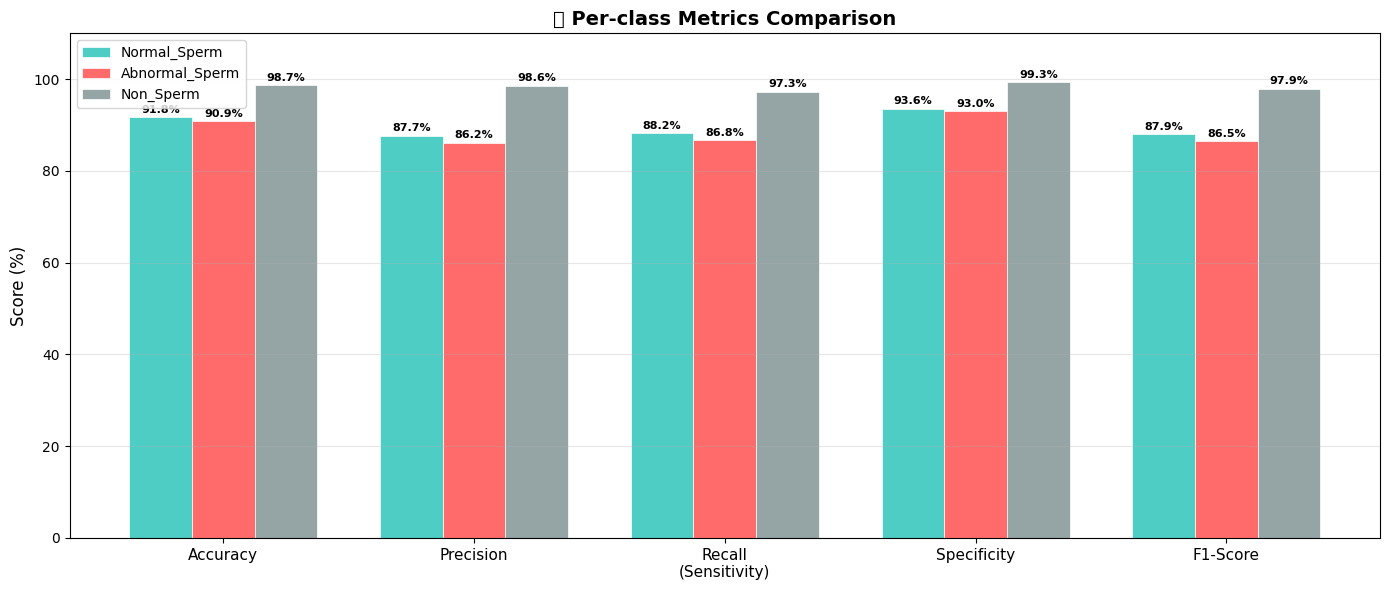

In [ ]:
# %% --- Cell 11b: Per-class Metrics Bar Chart ---
def plot_per_class_metrics(per_class):
    """Biểu đồ bar chart so sánh metrics giữa 3 lớp."""
    metrics = ['accuracy', 'precision', 'recall', 'specificity', 'f1']
    labels  = ['Accuracy', 'Precision', 'Recall\n(Sensitivity)', 'Specificity', 'F1-Score']
    classes = list(per_class.keys())
    colors  = ['#4ECDC4', '#FF6B6B', '#95A5A6']

    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (cls, color) in enumerate(zip(classes, colors)):
        vals = [per_class[cls][m] for m in metrics]
        bars = ax.bar(x + i*width, vals, width, label=cls, color=color, edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title('📊 Per-class Metrics Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/per_class_metrics.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_per_class_metrics(per_class)


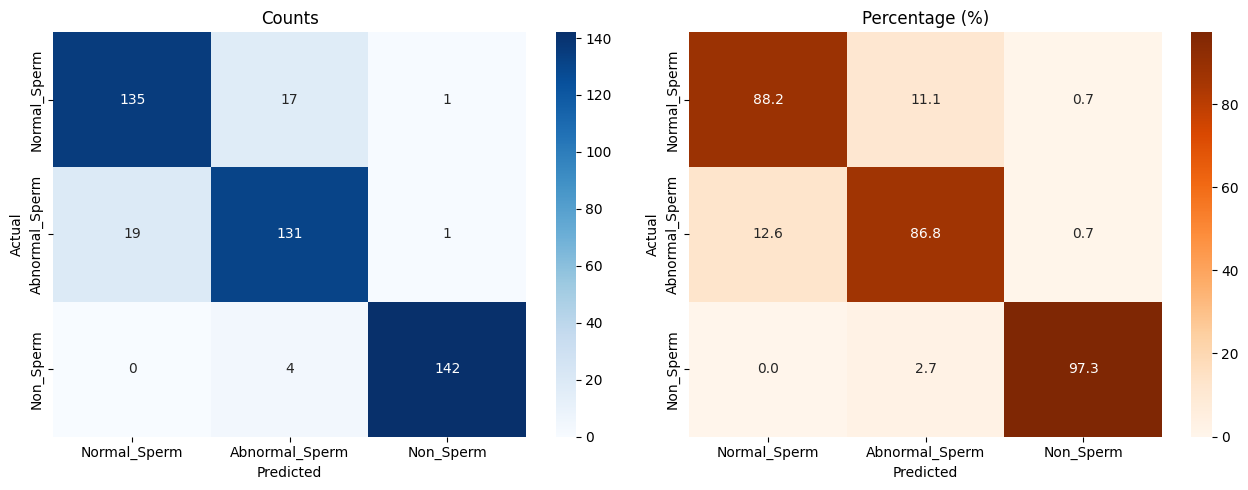

In [ ]:
# %% --- Cell 12: Confusion Matrix ---
def plot_cm(yt, yp):
    cm = confusion_matrix(yt, yp)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CONFIG.CLASS_NAMES,
                yticklabels=CONFIG.CLASS_NAMES, ax=ax[0])
    ax[0].set_title('Counts'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', xticklabels=CONFIG.CLASS_NAMES,
                yticklabels=CONFIG.CLASS_NAMES, ax=ax[1])
    ax[1].set_title('Percentage (%)'); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_cm(y_true, y_pred)


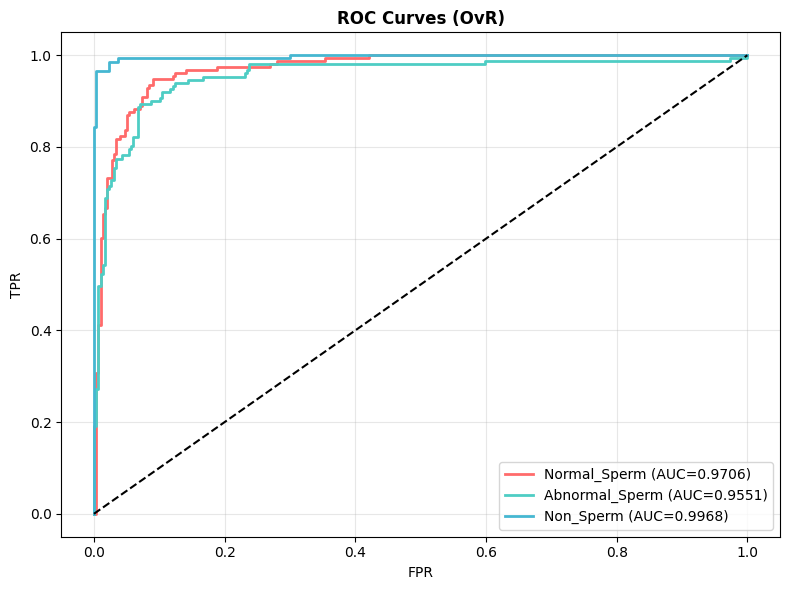

In [ ]:
# %% --- Cell 13: ROC Curves ---
def plot_roc(yt, yp):
    yb = label_binarize(yt, classes=[0,1,2])
    fig, ax = plt.subplots(figsize=(8,6))
    for i, (cls, c) in enumerate(zip(CONFIG.CLASS_NAMES, ['#FF6B6B','#4ECDC4','#45B7D1'])):
        fpr, tpr, _ = roc_curve(yb[:,i], yp[:,i])
        ax.plot(fpr, tpr, color=c, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.4f})')
    ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title('ROC Curves (OvR)', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/roc_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_roc(y_true, y_probs)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2103/3337342203.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.suptitle('❌ Misclassified', fontweight='bold'); plt.tight_layout()
/tmp/ipykernel_2103/3337342203.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CONFIG.FIGURES_DIR}/misclassified.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


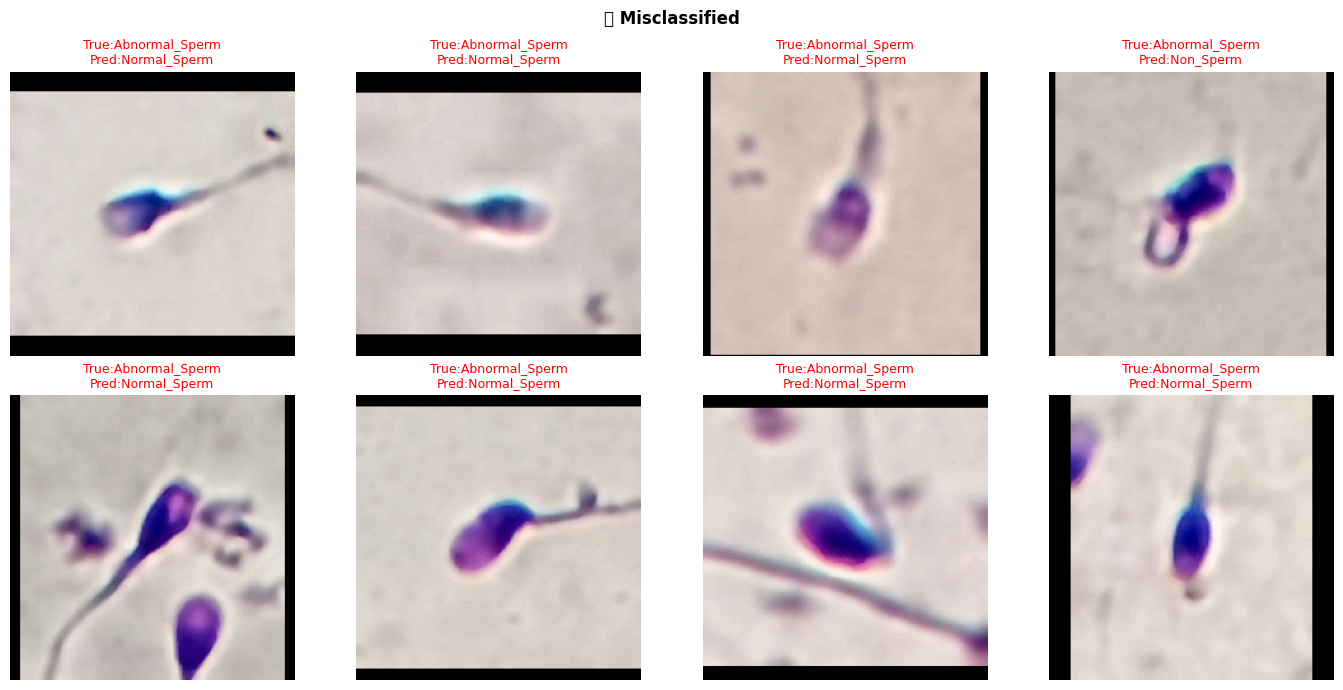

In [ ]:
# %% --- Cell 14: Misclassified Samples ---
def show_misclassified(model, loader, n=8):
    model.eval()
    wrong_imgs, wrong_p, wrong_l = [], [], []
    mean = torch.tensor(CONFIG.IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(CONFIG.IMAGENET_STD).view(3,1,1)
    with torch.no_grad():
        for imgs, labs in loader:
            out = model(imgs.to(DEVICE)); pred = out.argmax(1).cpu()
            mask = pred != labs
            if mask.any():
                wrong_imgs.extend(imgs[mask]); wrong_p.extend(pred[mask].numpy())
                wrong_l.extend(labs[mask].numpy())
            if len(wrong_imgs) >= n: break
    if not wrong_imgs: print("✅ No misclassified!"); return
    k = min(n, len(wrong_imgs)); cols=4; rows=(k+3)//4
    fig, ax = plt.subplots(rows, cols, figsize=(14, 3.5*rows))
    ax = np.array(ax).flatten()
    for i in range(k):
        im = (wrong_imgs[i]*std+mean).permute(1,2,0).numpy().clip(0,1)
        ax[i].imshow(im); ax[i].axis('off')
        ax[i].set_title(f"True:{CONFIG.CLASS_NAMES[wrong_l[i]]}\nPred:{CONFIG.CLASS_NAMES[wrong_p[i]]}", color='red', fontsize=9)
    for j in range(k, len(ax)): ax[j].axis('off')
    plt.suptitle('❌ Misclassified', fontweight='bold'); plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/misclassified.png", dpi=150, bbox_inches='tight')
    plt.show()

show_misclassified(model, test_loader)

In [ ]:
# %% --- Cell 15: Inference ---
def predict_image(image_path, model):
    proc = preprocess_image(image_path, CONFIG.IMAGE_SIZE)
    tensor = val_transforms(Image.fromarray(proc)).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=CONFIG.USE_AMP):
            logits = model(tensor)
        probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    idx = probs.argmax()
    return CONFIG.CLASS_NAMES[idx], probs[idx], probs

def predict_and_show(image_path, model):
    label, conf, probs = predict_image(image_path, model)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    ax[0].imshow(img); ax[0].set_title(f"{label} ({conf:.1%})", fontsize=13); ax[0].axis('off')
    bars = ax[1].barh(CONFIG.CLASS_NAMES, probs, color=['#4ECDC4','#FF6B6B','#95A5A6'])
    ax[1].set_xlim(0,1); ax[1].set_title('Probabilities', fontweight='bold')
    for b, p in zip(bars, probs): ax[1].text(b.get_width()+0.02, b.get_y()+b.get_height()/2, f'{p:.1%}', va='center')
    plt.tight_layout(); plt.show()
    return label, conf

predict_and_show("/path/to/image.jpg", model)


ValueError: Không đọc được: /path/to/image.jpg

📊 t-SNE VISUALIZATION — Features from Different Layers


Extracting features:   0%|          | 0/29 [00:00<?, ?it/s]

  Computing t-SNE for stage_2 (shape: (450, 48))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  Computing t-SNE for stage_4 (shape: (450, 128))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  Computing t-SNE for stage_6 (shape: (450, 256))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  Computing t-SNE for cbam_features (shape: (450, 1280))...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


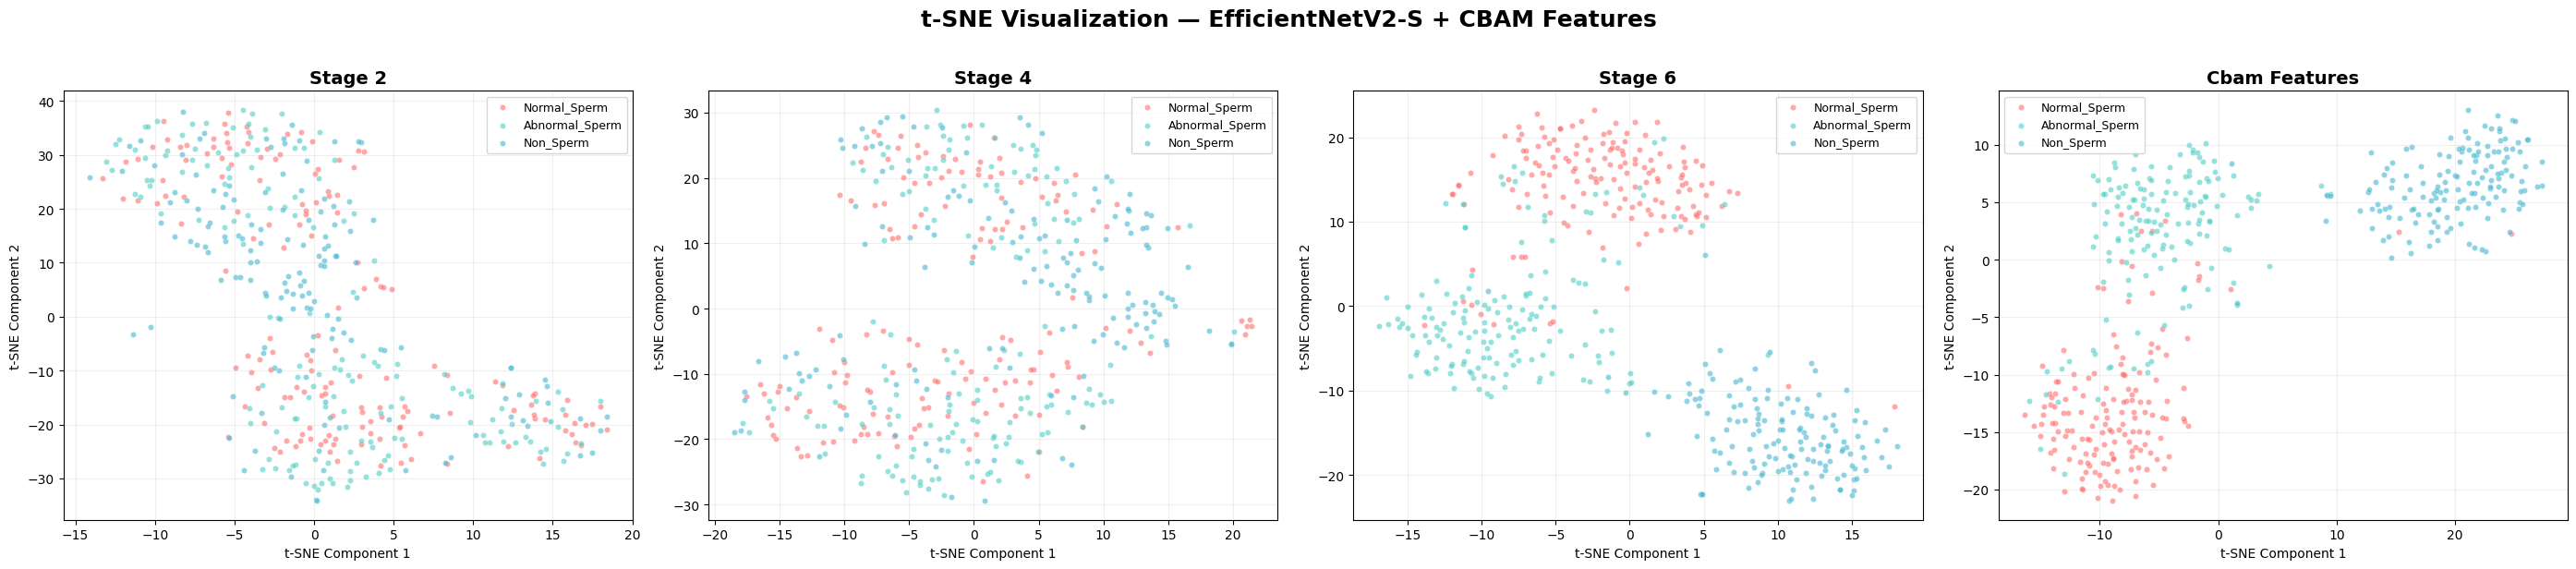

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


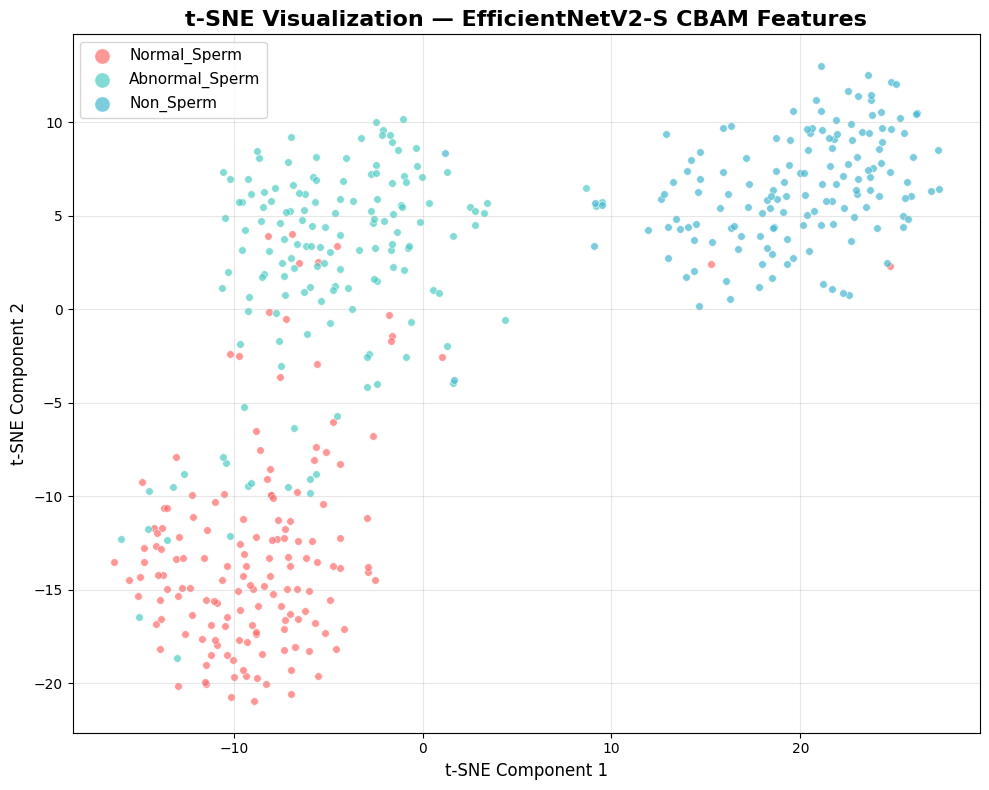

✅ t-SNE visualization complete!


In [ ]:
# %% --- t-SNE Feature Visualization (Multi-Layer) ---
from sklearn.manifold import TSNE

print("=" * 60)
print("📊 t-SNE VISUALIZATION — Features from Different Layers")
print("=" * 60)

@torch.no_grad()
def extract_features_all_layers(model, loader, max_samples=500):
    """Trích xuất features từ nhiều layers của EfficientNetV2-S + CBAM."""
    model.eval()
    all_feats = {}
    all_labels = []
    count = 0

    for imgs, labs in tqdm(loader, desc="Extracting features"):
        imgs = imgs.to(DEVICE)
        feats = model.extract_multi_layer_features(imgs)

        for key, feat in feats.items():
            if key not in all_feats:
                all_feats[key] = []
            all_feats[key].append(feat.cpu().numpy())

        all_labels.extend(labs.numpy())
        count += imgs.size(0)
        if count >= max_samples:
            break

    # Concatenate
    for key in all_feats:
        all_feats[key] = np.concatenate(all_feats[key], axis=0)[:max_samples]
    all_labels = np.array(all_labels)[:max_samples]

    return all_feats, all_labels

def plot_tsne_multi_layer(all_feats, labels, perplexity=30, n_iter=1000):
    """Plot t-SNE cho features từ nhiều layers."""
    layer_names = list(all_feats.keys())
    n_layers = len(layer_names)
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Abnormal, Normal, Non
    class_colors = [colors[l] for l in labels]

    fig, axes = plt.subplots(1, n_layers, figsize=(7 * n_layers, 6))
    if n_layers == 1: axes = [axes]

    fig.suptitle('t-SNE Visualization — EfficientNetV2-S + CBAM Features',
                 fontsize=18, fontweight='bold', y=1.02)

    for idx, (layer_name, ax) in enumerate(zip(layer_names, axes)):
        feats = all_feats[layer_name]
        print(f"  Computing t-SNE for {layer_name} (shape: {feats.shape})...")

        tsne = TSNE(n_components=2, perplexity=min(perplexity, len(feats)-1),
                     n_iter=n_iter, random_state=42, init='pca', learning_rate='auto')
        embedded = tsne.fit_transform(feats)

        for cls_idx in range(CONFIG.NUM_CLASSES):
            mask = labels == cls_idx
            ax.scatter(embedded[mask, 0], embedded[mask, 1],
                      c=colors[cls_idx], label=CONFIG.CLASS_NAMES[cls_idx],
                      alpha=0.6, s=20, edgecolors='white', linewidth=0.3)

        # Formatting
        layer_title = layer_name.replace('_', ' ').title()
        ax.set_title(f'{layer_title}', fontsize=14, fontweight='bold')
        ax.set_xlabel('t-SNE Component 1', fontsize=10)
        ax.set_ylabel('t-SNE Component 2', fontsize=10)
        ax.legend(fontsize=9, loc='best')
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/tsne_multi_layer.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # === Plot riêng CBAM features (lớn hơn) ===
    if 'cbam_features' in all_feats:
        fig2, ax2 = plt.subplots(figsize=(10, 8))
        feats_cbam = all_feats['cbam_features']
        tsne = TSNE(n_components=2, perplexity=min(30, len(feats_cbam)-1),
                     n_iter=1000, random_state=42, init='pca', learning_rate='auto')
        embedded = tsne.fit_transform(feats_cbam)

        for cls_idx in range(CONFIG.NUM_CLASSES):
            mask = labels == cls_idx
            ax2.scatter(embedded[mask, 0], embedded[mask, 1],
                       c=colors[cls_idx], label=CONFIG.CLASS_NAMES[cls_idx],
                       alpha=0.7, s=30, edgecolors='white', linewidth=0.5)

        ax2.set_title('t-SNE Visualization — EfficientNetV2-S CBAM Features',
                      fontsize=16, fontweight='bold')
        ax2.set_xlabel('t-SNE Component 1', fontsize=12)
        ax2.set_ylabel('t-SNE Component 2', fontsize=12)
        ax2.legend(fontsize=11, markerscale=2)
        ax2.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{CONFIG.FIGURES_DIR}/tsne_cbam_features.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

    print("✅ t-SNE visualization complete!")

# === RUN ===
all_feats, all_labels = extract_features_all_layers(model, test_loader, max_samples=500)
plot_tsne_multi_layer(all_feats, all_labels)

🔬 GRAD-CAM++ VISUAL INTERPRETABILITY ANALYSIS


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


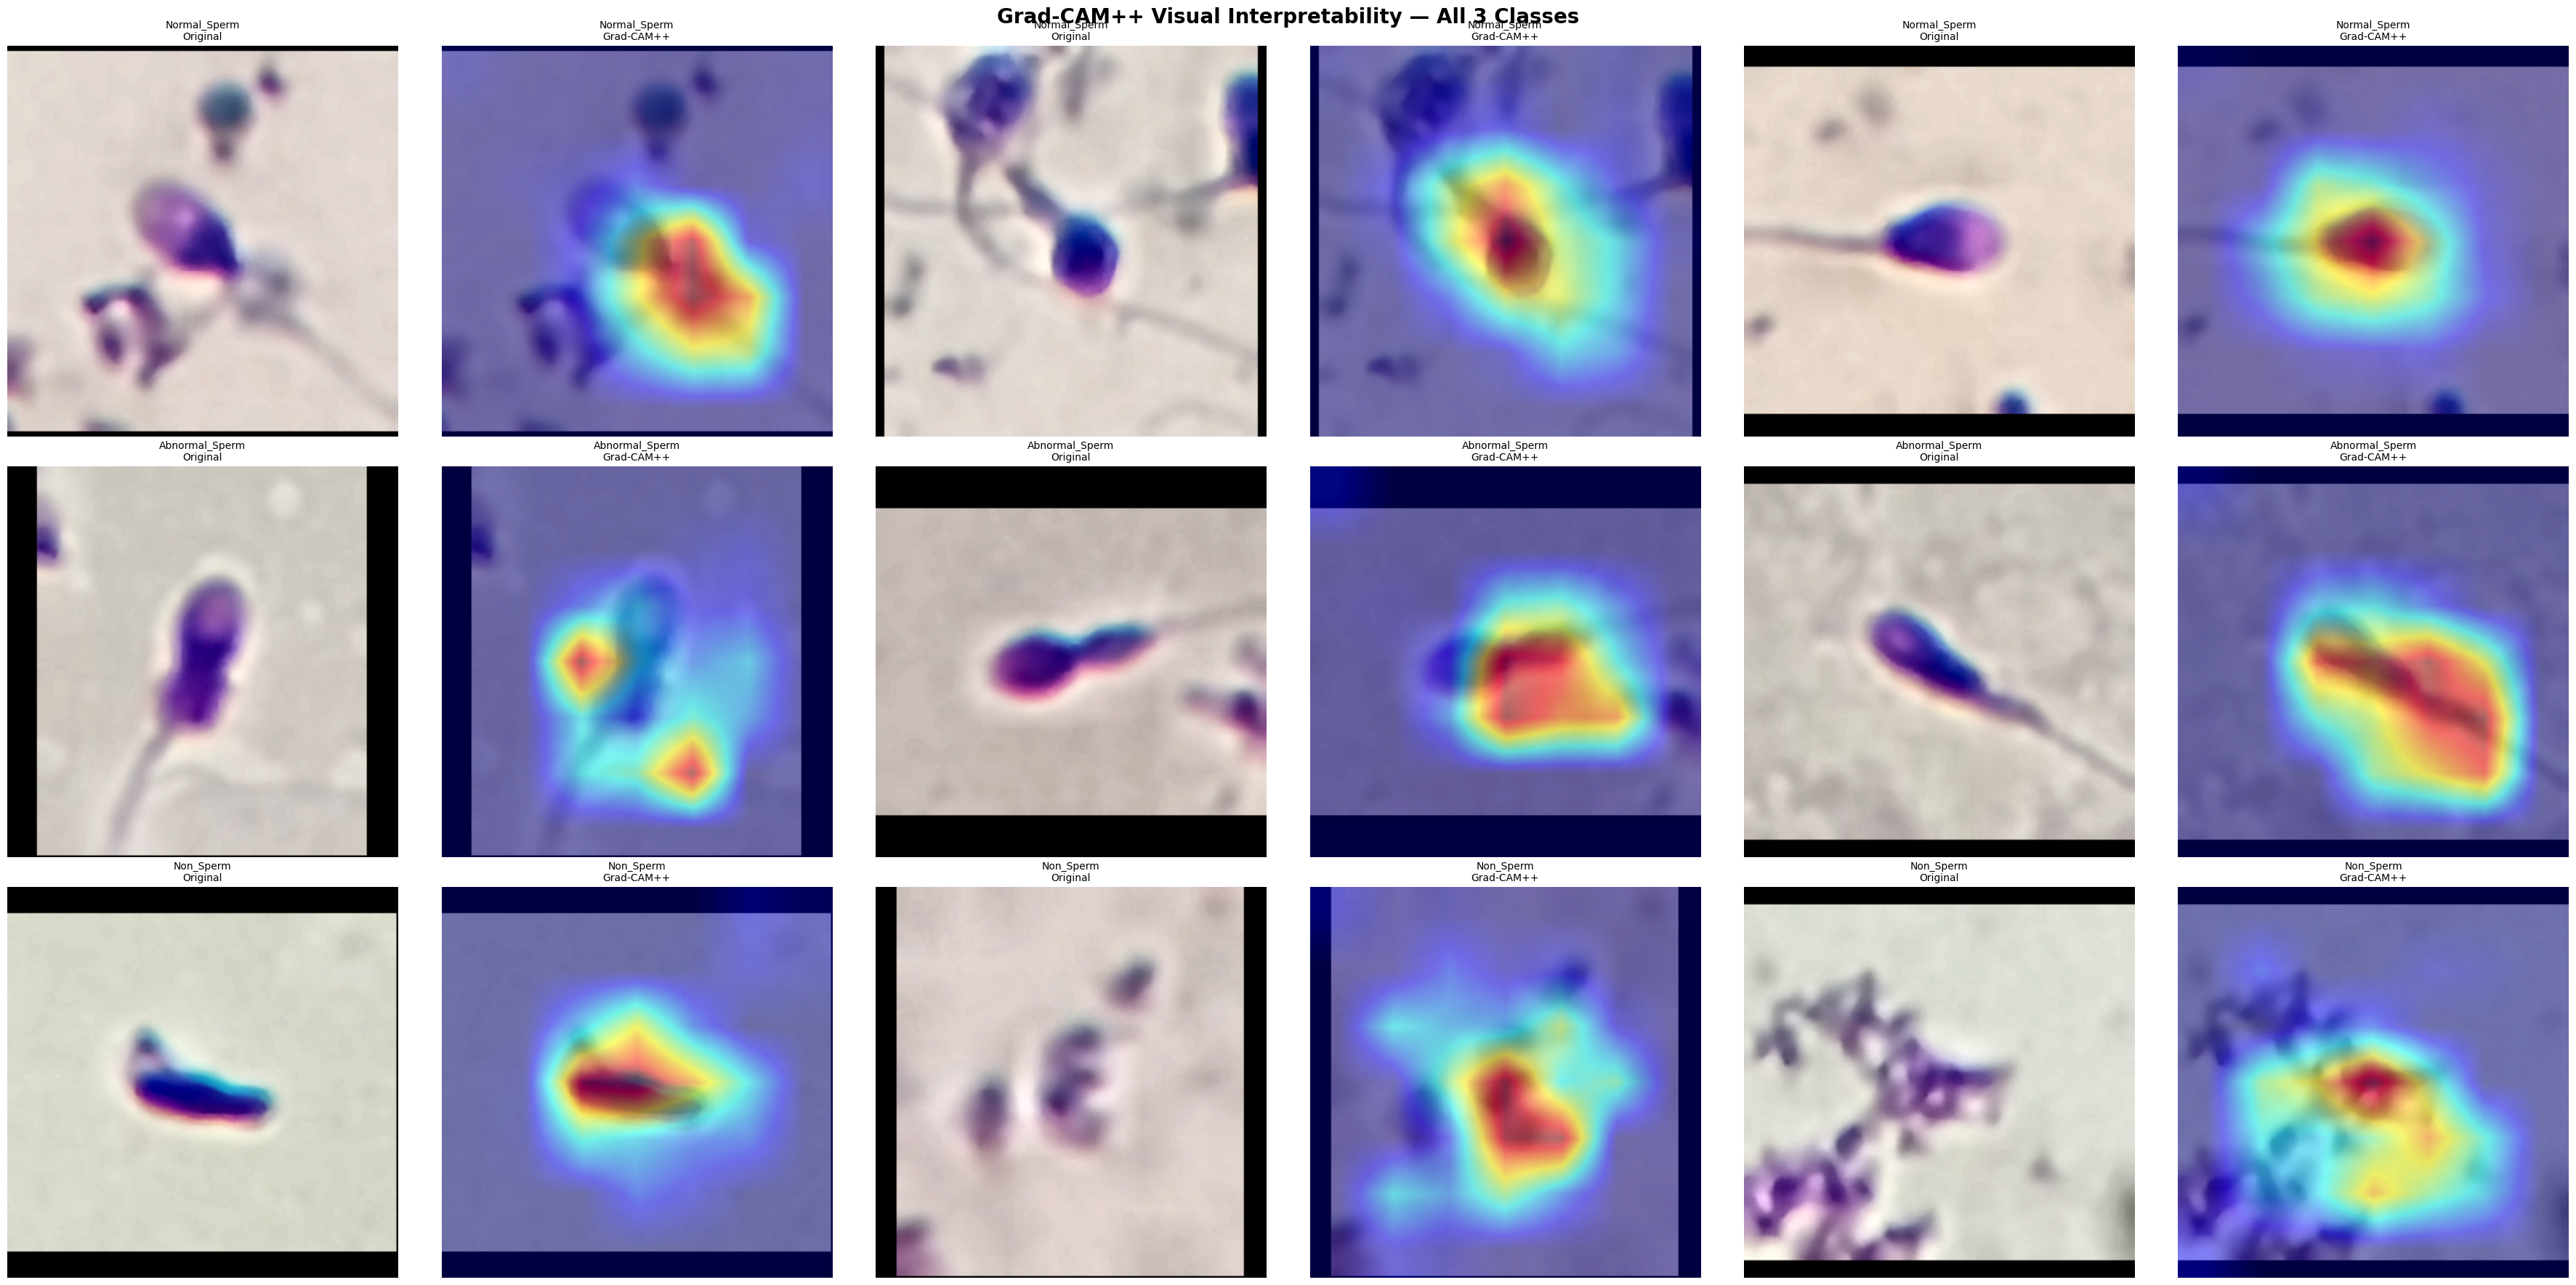

✅ Grad-CAM++ analysis saved!


In [ ]:
# %% --- XAI: Grad-CAM++ Visual Interpretability Analysis (3 lớp) ---
print("=" * 60)
print("🔬 GRAD-CAM++ VISUAL INTERPRETABILITY ANALYSIS")
print("=" * 60)

def xai_gradcampp_all_classes(model, test_loader, n_per_class=3):
    """Grad-CAM++ analysis cho cả 3 lớp: Normal, Abnormal, Non_Sperm."""
    target_layers = [model.cbam]
    cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

    # Thu thập mẫu từng lớp
    class_samples = {i: [] for i in range(CONFIG.NUM_CLASSES)}
    model.eval()
    for imgs, labs in test_loader:
        for img, lab in zip(imgs, labs):
            lab_idx = lab.item()
            if len(class_samples[lab_idx]) < n_per_class:
                class_samples[lab_idx].append(img)
        if all(len(v) >= n_per_class for v in class_samples.values()):
            break

    mean = np.array(CONFIG.IMAGENET_MEAN)
    std = np.array(CONFIG.IMAGENET_STD)

    # === Plot cho từng lớp ===
    fig, axes = plt.subplots(CONFIG.NUM_CLASSES, n_per_class * 2,
                              figsize=(6 * n_per_class * 2, 6 * CONFIG.NUM_CLASSES))
    fig.suptitle('Grad-CAM++ Visual Interpretability — All 3 Classes',
                 fontsize=20, fontweight='bold')

    for cls_idx in range(CONFIG.NUM_CLASSES):
        cls_name = CONFIG.CLASS_NAMES[cls_idx]
        for j, img_tensor in enumerate(class_samples[cls_idx]):
            input_t = img_tensor.unsqueeze(0).to(DEVICE)
            targets = [ClassifierOutputTarget(cls_idx)]

            # Denormalize
            rgb_img = img_tensor.permute(1, 2, 0).numpy() * std + mean
            rgb_img = np.clip(rgb_img, 0, 1).astype(np.float32)

            # Grad-CAM++
            gcpp_map = cam(input_tensor=input_t, targets=targets)
            gcpp_vis = show_cam_on_image(rgb_img, gcpp_map[0], use_rgb=True)

            col = j * 2
            axes[cls_idx, col].imshow(rgb_img)
            axes[cls_idx, col].set_title(f'{cls_name}\nOriginal', fontsize=10)
            axes[cls_idx, col + 1].imshow(gcpp_vis)
            axes[cls_idx, col + 1].set_title(f'{cls_name}\nGrad-CAM++', fontsize=10)
            for ax in axes[cls_idx, col:col+2]: ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"{CONFIG.FIGURES_DIR}/xai_gradcampp_all_classes.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grad-CAM++ analysis saved!")

xai_gradcampp_all_classes(model, test_loader, n_per_class=3)

In [ ]:
# %% --- XAI: Grad-CAM++ Single Image Analysis ---
def xai_single_image(model, image_path):
    """Phân tích Grad-CAM++ chi tiết cho 1 ảnh."""
    target_layers = [model.cbam]
    cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

    img_orig = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    img_proc = preprocess_image(image_path, CONFIG.IMAGE_SIZE)
    tensor = val_transforms(Image.fromarray(img_proc)).unsqueeze(0).to(DEVICE)

    # Predict
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    pred_idx = int(probs.argmax())

    # RGB cho overlay
    mean = np.array(CONFIG.IMAGENET_MEAN)
    std = np.array(CONFIG.IMAGENET_STD)
    rgb_img = tensor.squeeze().permute(1,2,0).cpu().numpy() * std + mean
    rgb_img = np.clip(rgb_img, 0, 1).astype(np.float32)

    # Grad-CAM++
    targets = [ClassifierOutputTarget(pred_idx)]
    gcpp_map = cam(input_tensor=tensor, targets=targets)
    gcpp_vis = show_cam_on_image(rgb_img, gcpp_map[0], use_rgb=True)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_orig); axes[0].set_title('Original', fontsize=12); axes[0].axis('off')
    axes[1].imshow(rgb_img); axes[1].set_title('Preprocessed', fontsize=12); axes[1].axis('off')
    axes[2].imshow(gcpp_vis); axes[2].set_title('Grad-CAM++', fontsize=12); axes[2].axis('off')
    bars = axes[3].barh(CONFIG.CLASS_NAMES, probs, color=['#4ECDC4','#FF6B6B','#95A5A6'])
    axes[3].set_title(f'Pred: {CONFIG.CLASS_NAMES[pred_idx]} ({probs[pred_idx]:.1%})')
    axes[3].set_xlim(0, 1)
    for b, p in zip(bars, probs):
        axes[3].text(b.get_width()+0.02, b.get_y()+b.get_height()/2, f'{p:.1%}', va='center')
    plt.tight_layout(); plt.show()
    return CONFIG.CLASS_NAMES[pred_idx], probs[pred_idx]

# Ví dụ sử dụng (đổi đường dẫn):
# xai_single_image(model, "/path/to/image.jpg")
print("✅ xai_single_image() ready — dùng: xai_single_image(model, 'path/to/image.jpg')")

✅ xai_single_image() ready — dùng: xai_single_image(model, 'path/to/image.jpg')


END